# 전력 Peak 발생 요인 분석

공장 전력 사용량(`평균`, kW)의 **Peak가 언제, 어떤 조건에서 생기는지** 분석한다.

| 절 | 내용 |
|---|---|
| 1~4 | 데이터 준비 · 하루 전력 곡선 · 일별 Peak 탐지 (`scipy.signal.find_peaks`) |
| 5~6 | 평일/주말 Peak 통계 · 발생 시간대 · 변수와의 관계 · 상관계수 |
| 7 | 시차(Lag) · 이동평균(Rolling) · 주기(sin/cos) 변수 생성 |
| 8 | 계절 · 근무구분별 대표 전력 패턴과 Peak 시간 |
| 9 | OLS 회귀 (현재값 vs 직전 정보) |
| 10~11 | XGBoost 회귀 + SHAP 변수 중요도 (평일 vs 주말) |
| 12~14 | Peak prominence · 하루 내 Peak 순위 · 요약 테이블 |
| 15 | 상위 Peak 그룹 분석 (K-Means 계층 분류, 원인 추정) |
| 16 | 생산량 구간별 기온 · 습도와 전력의 관계 |
| 17 | 결과 저장 |

- **입력**: `okm_augumented_2021_processed.xlsx`
- **출력**: `peak_factor_analysis_result.xlsx`

## 0. 환경 설정
SHAP 버전을 0.49.1로 고정해 설치한다 (설치 후 커널 재시작 필요할 수 있음).

In [1]:
# 설치된 SHAP 제거
%pip uninstall -y shap

Found existing installation: shap 0.49.1
Uninstalling shap-0.49.1:
  Successfully uninstalled shap-0.49.1
Note: you may need to restart the kernel to use updated packages.


In [2]:
# SHAP 0.49.1 설치 (의존성 변경 없이)
%pip install --user --no-deps shap==0.49.1

  Using cached shap-0.49.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (25 kB)
Using cached shap-0.49.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (1.0 MB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings

warnings.filterwarnings('ignore')

# Peak 탐지
from scipy.signal import find_peaks

# 통계 분석
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# 머신러닝
from xgboost import XGBRegressor

# SHAP
import shap

# ---------------------------------------------------------
# 한글 폰트
# ---------------------------------------------------------

font_list = [f.name for f in fm.fontManager.ttflist]

if 'NanumGothic' in font_list:
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False

print("분석 환경 설정 완료")

/home/kampuser/.local/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/kampuser/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.4.0' currently installed).
  from pandas.core import (


분석 환경 설정 완료


## 1. 데이터 불러오기 및 점검

In [4]:
file_path = 'okm_augumented_2021_processed.xlsx'

df = pd.read_excel(file_path)

df['datetime'] = pd.to_datetime(df['datetime'])

# 시간순 정렬
df = df.sort_values('datetime').reset_index(drop=True)

print("데이터 크기:", df.shape)

print("\n[결측치]")
print(df.isna().sum())

print("\n[중복 datetime]")
print(df['datetime'].duplicated().sum())

print("\n[시간 간격]")
print(
    df['datetime']
    .diff()
    .value_counts()
    .head(10)
)

# 1~9월 데이터
data = df[
    (df['m'] >= 1) &
    (df['m'] <= 9)
].copy()

data = data.reset_index(drop=True)

print("1~9월 데이터 크기:", data.shape)

print(
    "분석 시작:",
    data['datetime'].min()
)

print(
    "분석 종료:",
    data['datetime'].max()
)

데이터 크기: (6168, 24)

[결측치]
날짜          0
시간          0
15분         0
30분         0
45분         0
60분         0
평균          0
생산량         0
기온          0
풍속          0
습도          0
강수량         0
전기요금(계절)    0
day         0
d           0
m           0
공장인원        0
인건비         0
시간복원        0
datetime    0
전력 구간합계     0
전력 최대값      0
전력 최소값      0
전력 변동폭      0
dtype: int64

[중복 datetime]
0

[시간 간격]
datetime
0 days 01:00:00    6167
Name: count, dtype: int64
1~9월 데이터 크기: (6168, 24)
분석 시작: 2021-01-01 00:00:00
분석 종료: 2021-09-14 23:00:00


## 2. 날짜 · 요일 변수 생성

In [5]:
# 날짜 · 요일 · 평일/주말 · 시각 · 월
data['date'] = data['datetime'].dt.date

data['weekday_num'] = data['datetime'].dt.weekday

data['weekday_name'] = data['datetime'].dt.day_name()

data['is_weekend'] = (
    data['weekday_num'] >= 5
).astype(int)

data['day_type'] = np.where(
    data['is_weekend'] == 1,
    '주말',
    '평일'
)

data['hour'] = data['datetime'].dt.hour

data['month'] = data['datetime'].dt.month

print(
    data[
        [
            'datetime',
            'date',
            'weekday_name',
            'day_type',
            'hour'
        ]
    ].head(10)
)

             datetime        date weekday_name day_type  hour
0 2021-01-01 00:00:00  2021-01-01       Friday       평일     0
1 2021-01-01 01:00:00  2021-01-01       Friday       평일     1
2 2021-01-01 02:00:00  2021-01-01       Friday       평일     2
3 2021-01-01 03:00:00  2021-01-01       Friday       평일     3
4 2021-01-01 04:00:00  2021-01-01       Friday       평일     4
5 2021-01-01 05:00:00  2021-01-01       Friday       평일     5
6 2021-01-01 06:00:00  2021-01-01       Friday       평일     6
7 2021-01-01 07:00:00  2021-01-01       Friday       평일     7
8 2021-01-01 08:00:00  2021-01-01       Friday       평일     8
9 2021-01-01 09:00:00  2021-01-01       Friday       평일     9


## 3. 하루 전력 곡선 확인 (처음 5일)

In [6]:
# 특정 날짜의 24시간 전력 곡선
def plot_daily_load(
    data,
    target_date,
    value_col='평균'
):
    
    day_data = data[
        data['date'] == target_date
    ].sort_values('datetime')
    
    if len(day_data) == 0:
        print("해당 날짜의 데이터가 없습니다.")
        return
    
    plt.figure(figsize=(12, 5))
    
    plt.plot(
        day_data['datetime'],
        day_data[value_col],
        marker='o'
    )
    
    plt.title(
        f"{target_date} 전력 사용량"
    )
    
    plt.xlabel("시간")
    plt.ylabel("전력 사용량")
    
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

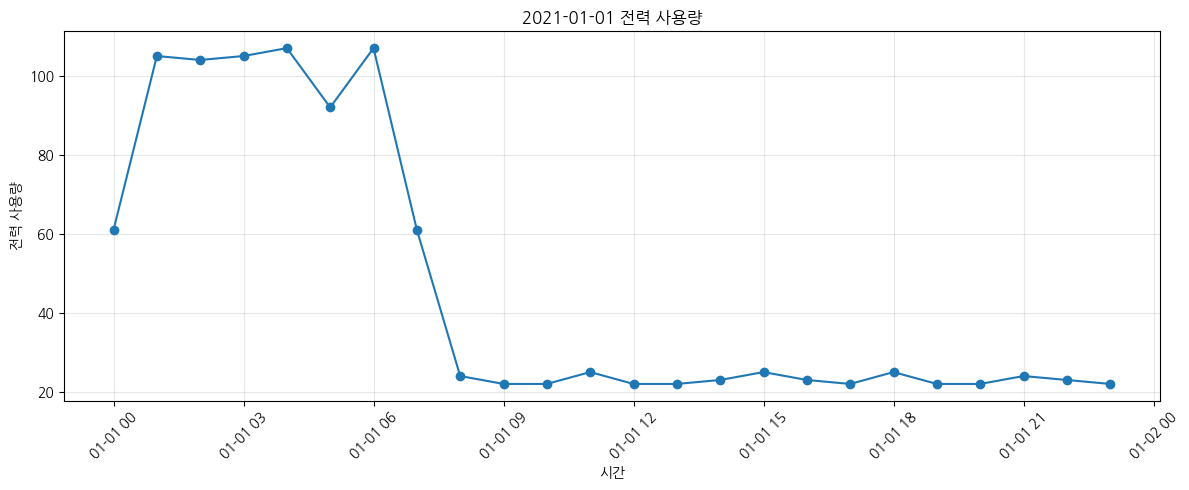

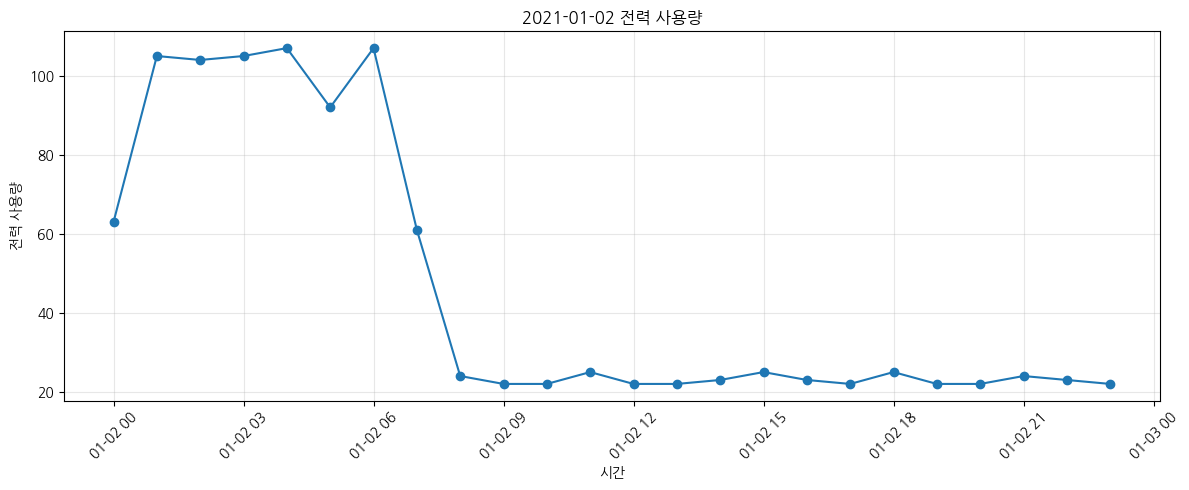

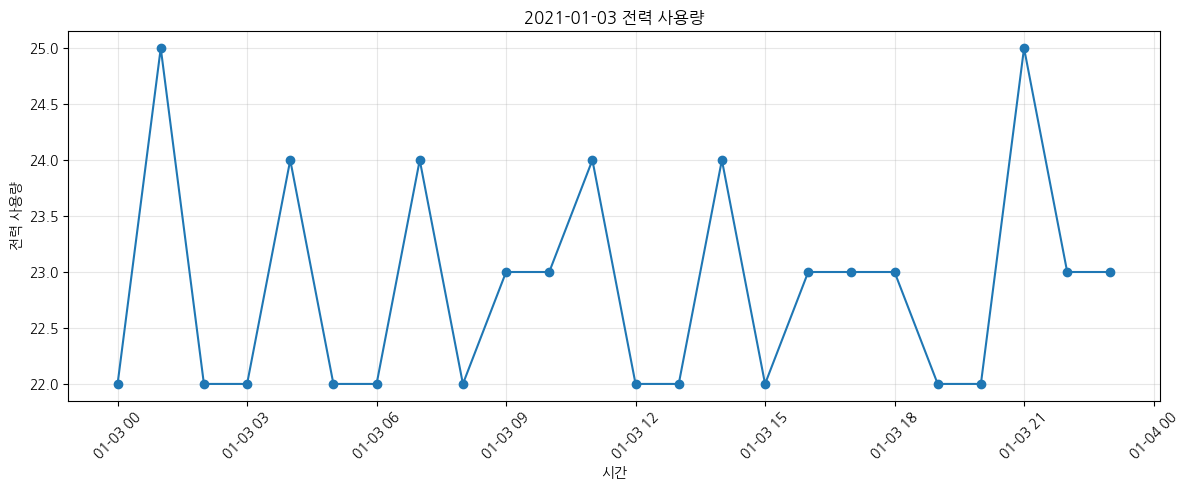

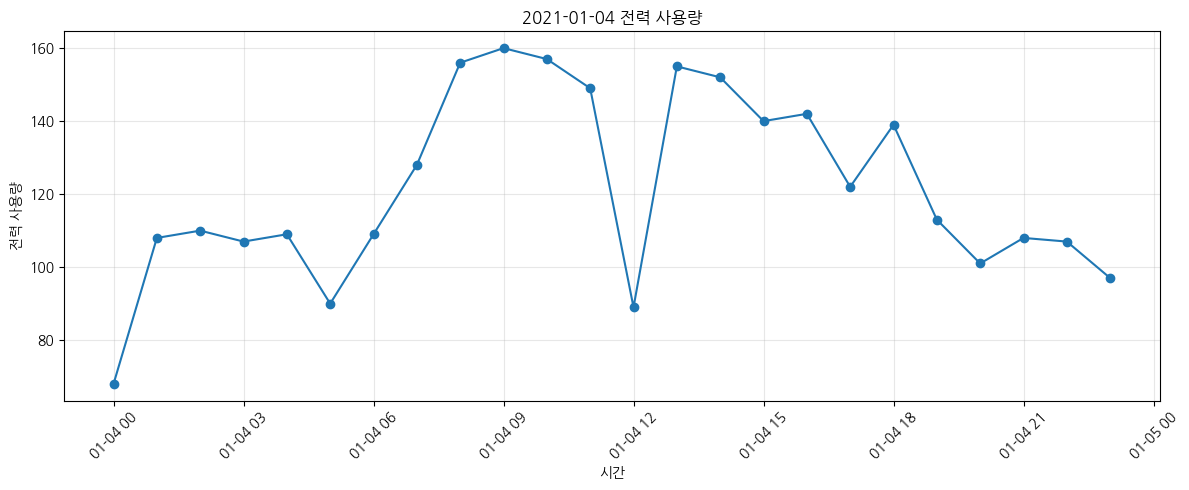

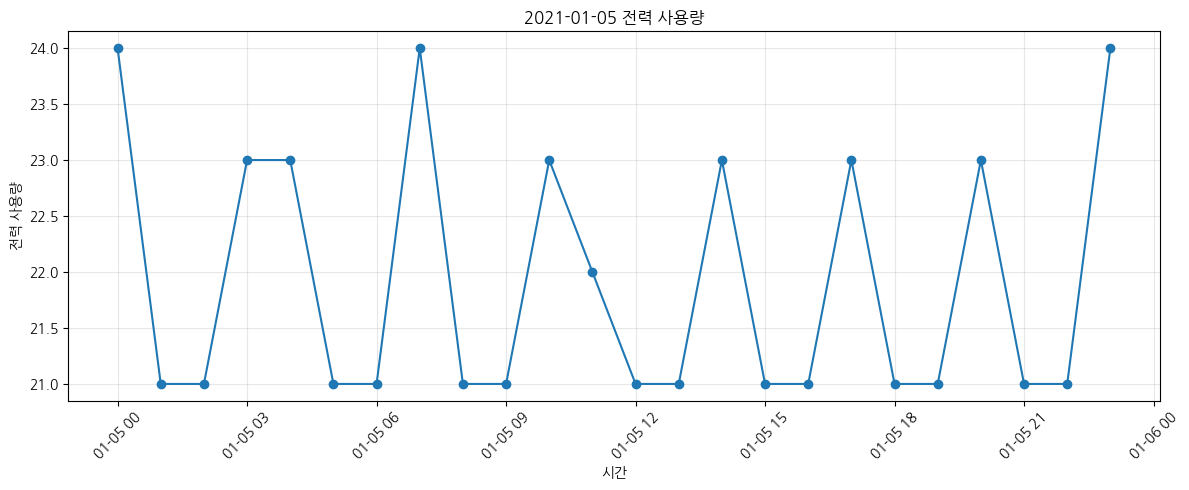

In [7]:
sample_dates = (
    data['date']
    .drop_duplicates()
    .head(5)
    .tolist()
)

for target_date in sample_dates:
    
    plot_daily_load(
        data,
        target_date
    )

## 4. 일별 Peak 탐지
`scipy.signal.find_peaks`로 하루 곡선의 Peak를 찾는다.
- `prominence` = 그날 전력 변동폭(최대 − 최소) × 8%
- `distance` = 2시간 (Peak 사이 최소 간격)
- 하루 Peak 후보가 3개를 넘으면 전력이 큰 3개만 사용

In [8]:
distance=2

# 하루 데이터에서 Peak 탐지 (prominence = 그날 변동폭 x prominence_ratio)
def detect_daily_peaks(
    day_df,
    value_col='평균',
    prominence_ratio=0.08,
    distance=2
):
    
    day_df = day_df.sort_values('datetime').copy()
    
    y = day_df[value_col].values
    
    # 해당 날짜의 전력 변동폭
    data_range = y.max() - y.min()
    
    # 변동폭의 일정 비율을 prominence 기준으로 사용
    prominence = data_range * prominence_ratio
    
    peak_idx, properties = find_peaks(
        y,
        prominence=prominence,
        distance=distance
    )
    
    peaks = day_df.iloc[peak_idx].copy()
    
    if len(peaks) > 0:
        peaks['peak_prominence'] = (
            properties['prominences']
        )
    
    return peaks

In [9]:

# 날짜별 Peak 탐지
peak_list = []

for target_date, day_df in data.groupby('date'):
    
    peaks = detect_daily_peaks(
        day_df,
        value_col='평균',
        prominence_ratio=0.08,
        distance=2
    )
    
    if len(peaks) > 3:
        # 하루 Peak 후보가 3개를 넘으면 전력이 가장 큰 3개만 사용
        peaks = (
            peaks
            .sort_values('평균', ascending=False)
            .head(3)
        )

    if len(peaks) > 0:
        peak_list.append(peaks)

peak_df = pd.concat(
    peak_list,
    ignore_index=True
)

print("탐지된 Peak 개수:", len(peak_df))

print(
    "Peak가 탐지된 날짜:",
    peak_df['date'].nunique()
)

display(
    peak_df[
        [
            'datetime',
            '평균',
            'peak_prominence'
        ]
    ].head(20)
)

탐지된 Peak 개수: 734
Peak가 탐지된 날짜: 257


,datetime,평균,peak_prominence
0,2021-01-01 04:00:00,107,46.0
1,2021-01-01 06:00:00,107,46.0
2,2021-01-02 04:00:00,107,44.0
3,2021-01-02 06:00:00,107,44.0
4,2021-01-03 01:00:00,25,3.0
5,2021-01-03 21:00:00,25,2.0
6,2021-01-03 04:00:00,24,2.0
7,2021-01-04 09:00:00,160,71.0
8,2021-01-04 13:00:00,155,58.0
9,2021-01-04 18:00:00,139,17.0


### 4-1. Peak 탐지 결과 확인 (처음 10일)

In [10]:
# 전력 곡선 위에 탐지된 Peak 표시
def plot_daily_peaks(
    data,
    peak_df,
    target_date,
    value_col='평균'
):
    
    day_data = data[
        data['date'] == target_date
    ].sort_values('datetime')
    
    day_peaks = peak_df[
        peak_df['date'] == target_date
    ].sort_values('datetime')
    
    plt.figure(figsize=(12, 5))
    
    # 전체 전력곡선
    plt.plot(
        day_data['datetime'],
        day_data[value_col],
        marker='o',
        label='전력 사용량'
    )
    
    # Peak 표시
    if len(day_peaks) > 0:
        
        plt.scatter(
            day_peaks['datetime'],
            day_peaks[value_col],
            s=100,
            label='Detected Peak',
            zorder=5
        )
    
    plt.title(
        f"{target_date} Peak 탐지 결과"
    )
    
    plt.xlabel("시간")
    plt.ylabel("전력 사용량")
    
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

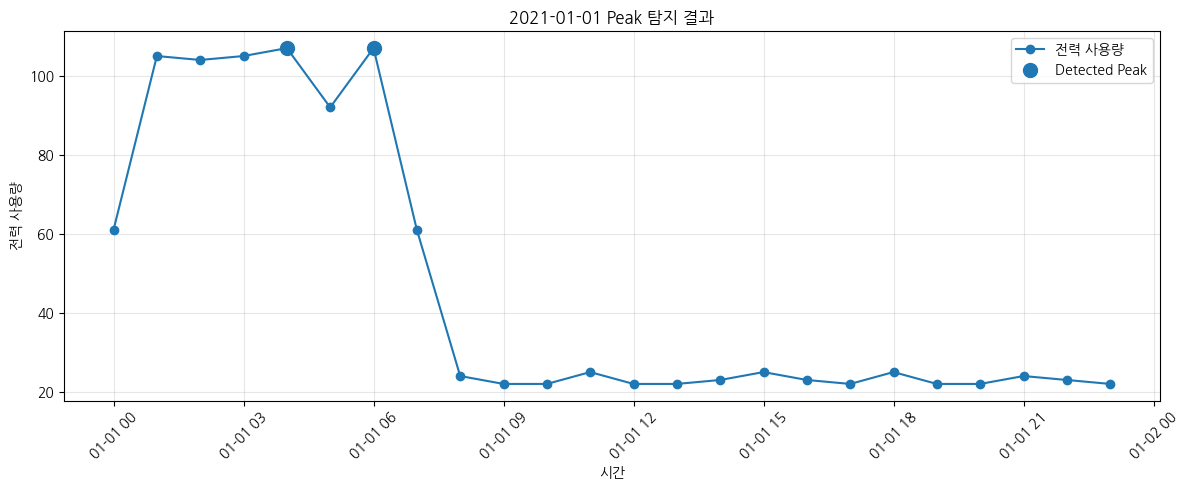

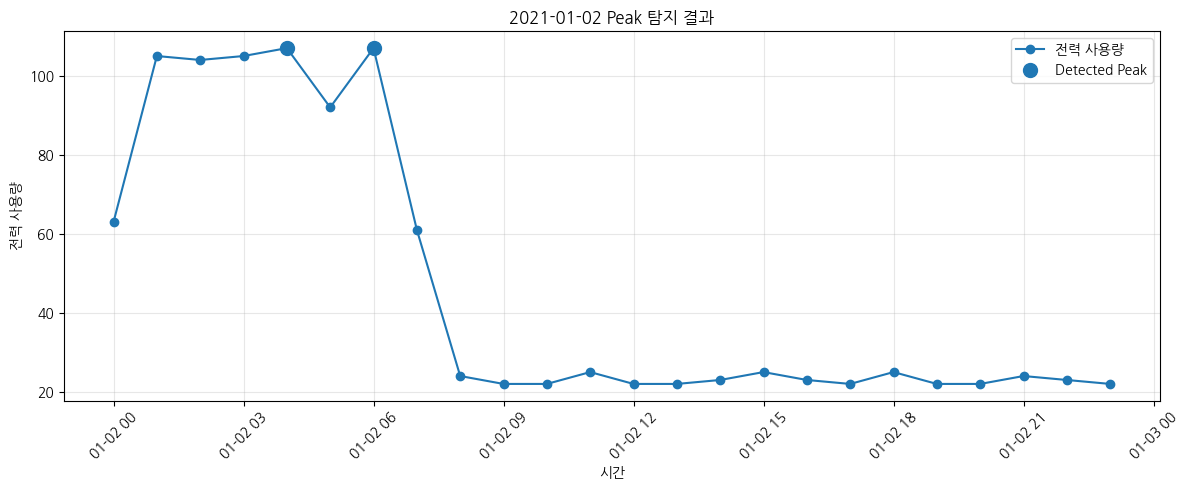

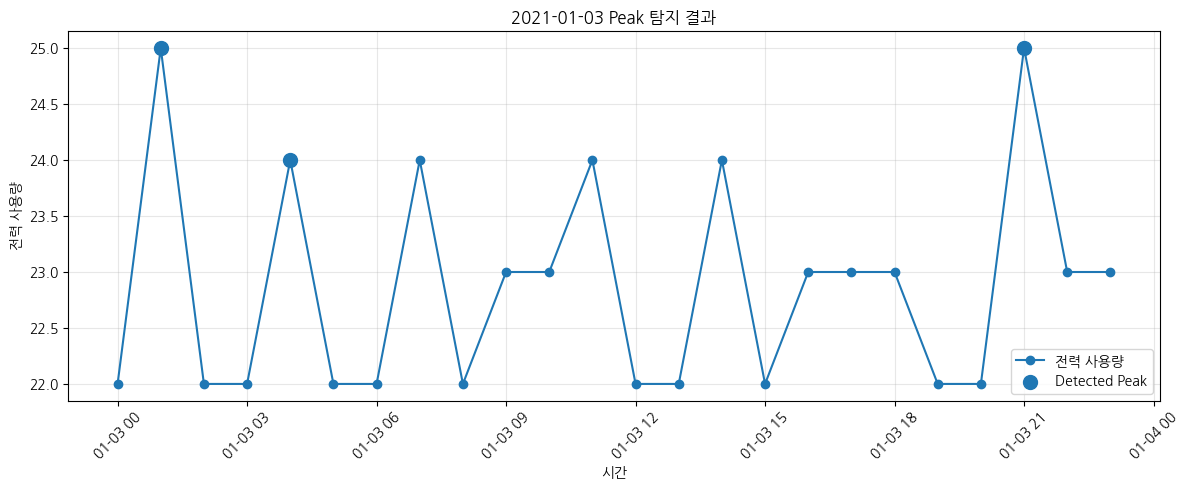

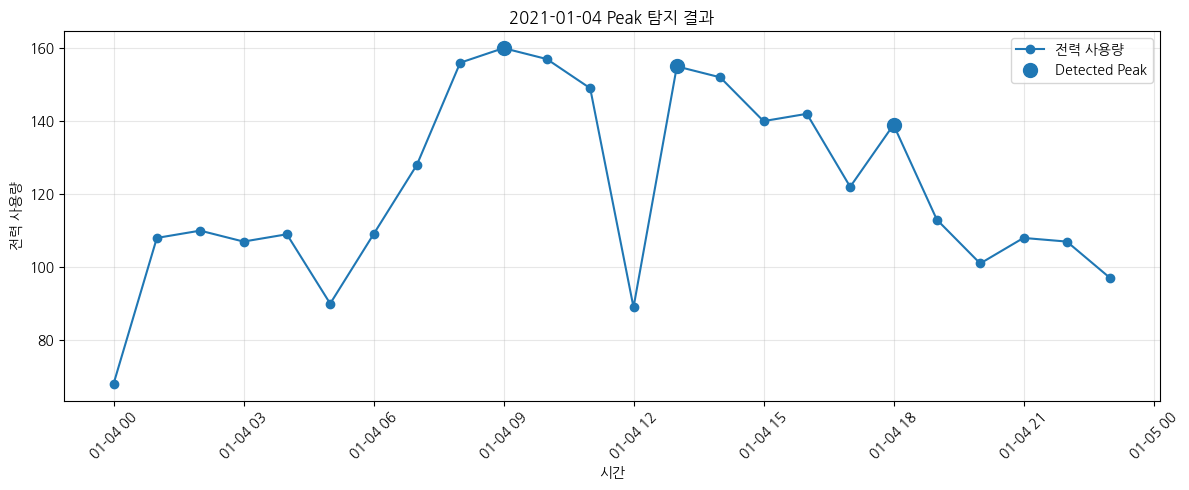

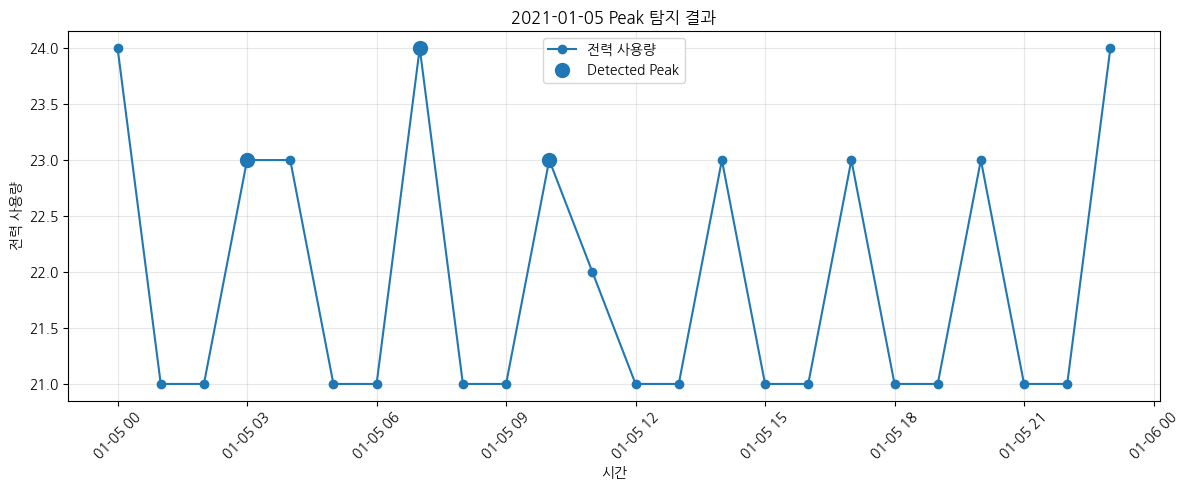

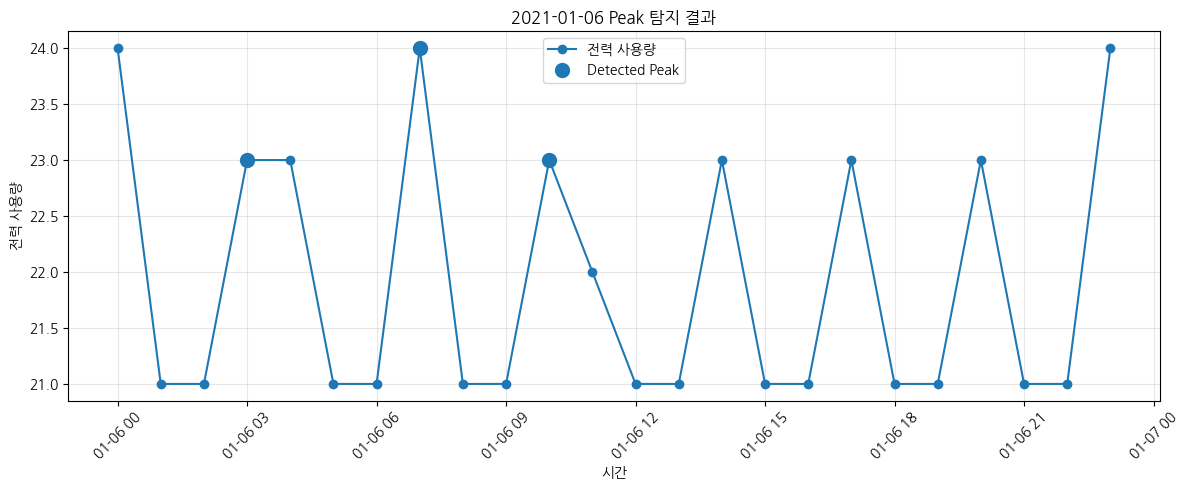

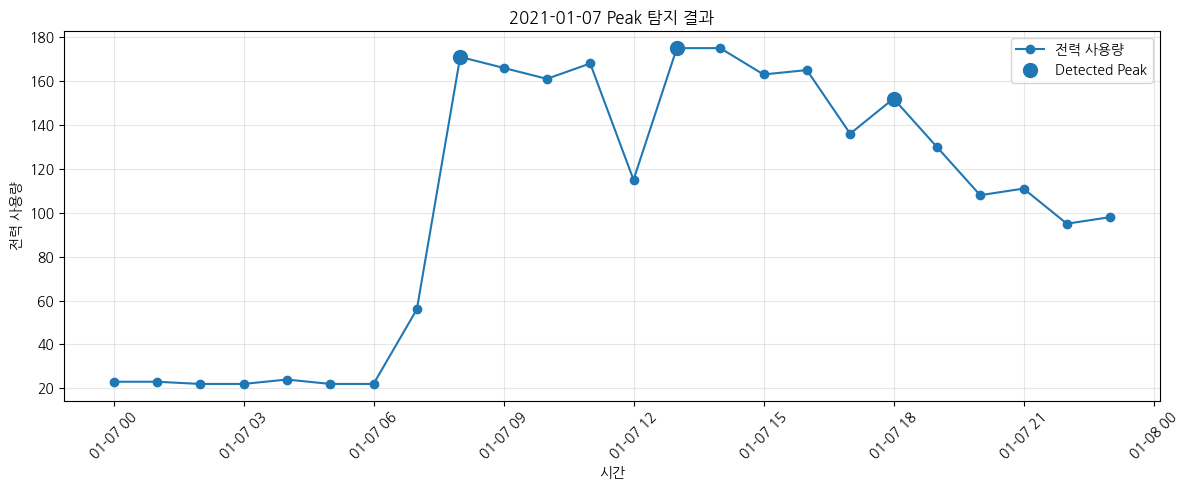

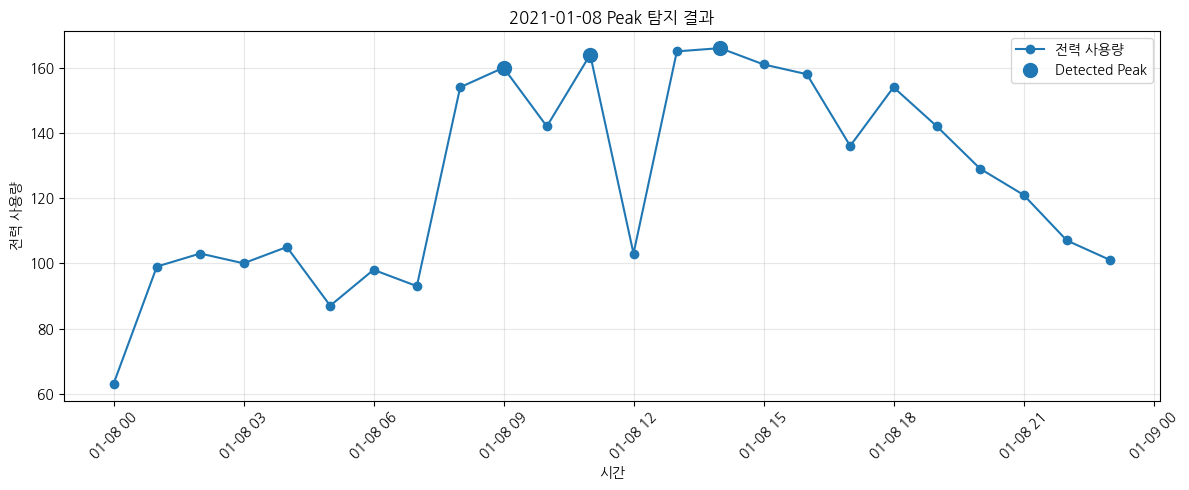

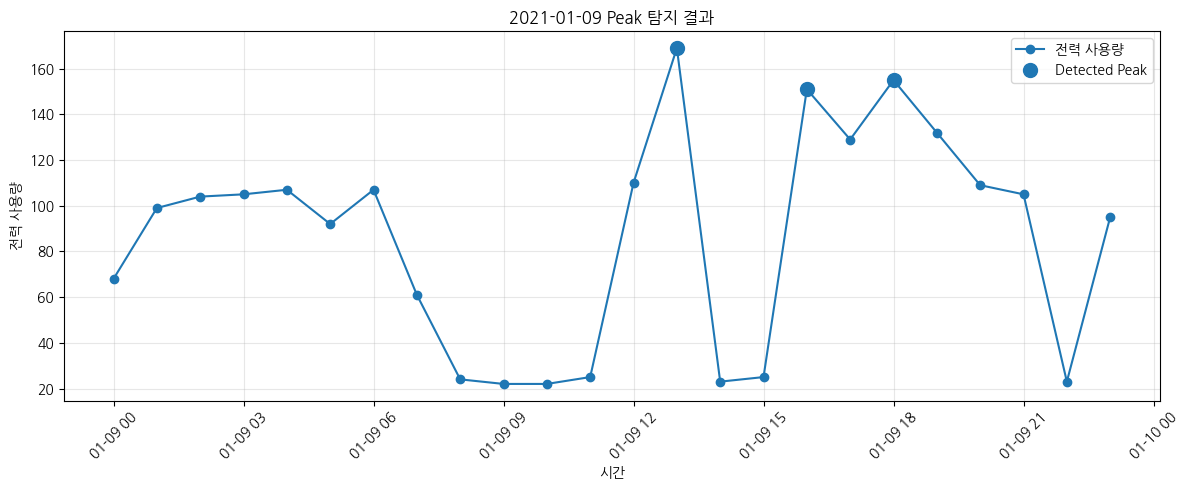

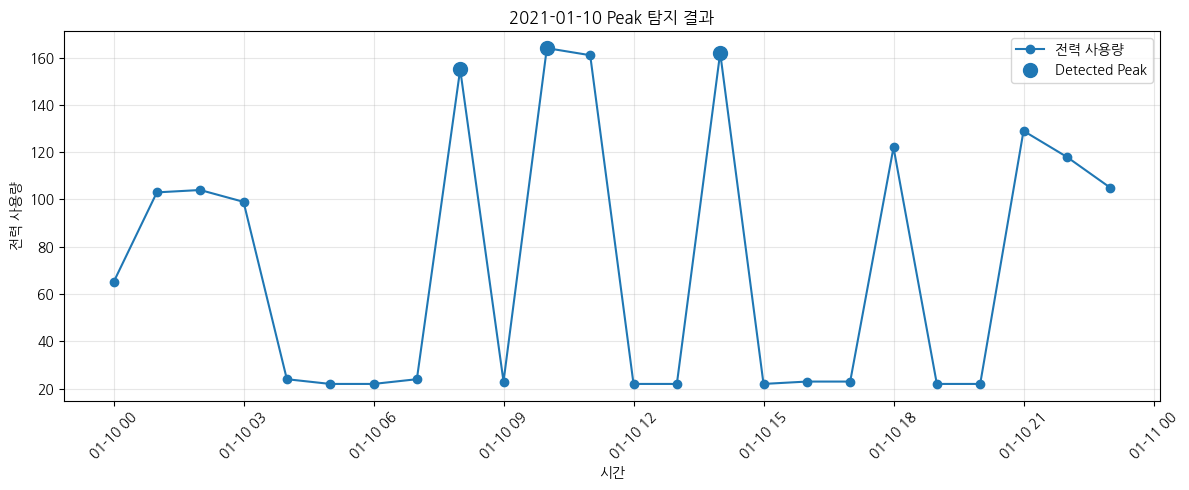

In [11]:
sample_dates = (
    peak_df['date']
    .drop_duplicates()
    .head(10)
    .tolist()
)

for target_date in sample_dates:
    
    plot_daily_peaks(
        data,
        peak_df,
        target_date
    )

### 4-2. 하루 Peak 개수 분포

In [12]:
daily_peak_count = (
    peak_df
    .groupby('date')
    .size()
    .reset_index(name='peak_count')
)

print("하루 Peak 개수 분포")
print(
    daily_peak_count['peak_count']
    .value_counts()
    .sort_index()
)

print("\n하루 평균 Peak 개수:")
print(
    daily_peak_count['peak_count'].mean()
)

하루 Peak 개수 분포
peak_count
1      2
2     33
3    222
Name: count, dtype: int64

하루 평균 Peak 개수:
2.8560311284046693


## 5. 평일 / 주말 Peak 데이터셋

In [13]:
# Peak 데이터에 평일/주말 · Peak 시각 · 월 · Peak 크기 추가
peak_df = peak_df.copy()

peak_df['weekday_num'] = (
    peak_df['datetime'].dt.weekday
)

peak_df['day_type'] = np.where(
    peak_df['weekday_num'] >= 5,
    '주말',
    '평일'
)

peak_df['peak_hour'] = (
    peak_df['datetime'].dt.hour
)

peak_df['month'] = (
    peak_df['datetime'].dt.month
)

peak_df['peak_value'] = (
    peak_df['평균']
)

print(
    peak_df.shape
)

display(
    peak_df[
        [
            'datetime',
            'day_type',
            'peak_hour',
            'peak_value',
            '생산량',
            '공장인원',
            '기온',
            '습도',
            '풍속',
            '강수량'
        ]
    ].head(20)
)

(734, 34)


,datetime,day_type,peak_hour,peak_value,생산량,공장인원,기온,습도,풍속,강수량
0,2021-01-01 04:00:00,평일,4,107,0,0.000000,-4.6,60,2.6,0.0
1,2021-01-01 06:00:00,평일,6,107,0,0.000000,-5.6,67,1.5,0.0
2,2021-01-02 04:00:00,주말,4,107,0,0.000000,-1.4,74,1.8,0.0
3,2021-01-02 06:00:00,주말,6,107,0,0.000000,-0.7,68,2.1,0.0
4,2021-01-03 01:00:00,주말,1,25,0,0.000000,-2.5,35,2.1,0.0
5,2021-01-03 21:00:00,주말,21,25,0,0.000000,0.4,37,2.3,0.0
6,2021-01-03 04:00:00,주말,4,24,0,0.000000,-2.2,35,3.3,0.0
7,2021-01-04 09:00:00,평일,9,160,313,0.488300,-1.5,48,2.4,0.0
8,2021-01-04 13:00:00,평일,13,155,791,1.273752,5.4,32,3.1,0.0
9,2021-01-04 18:00:00,평일,18,139,0,0.000000,3.1,42,1.5,0.0


In [14]:
weekday_peak = peak_df[
    peak_df['day_type'] == '평일'
].copy()

weekend_peak = peak_df[
    peak_df['day_type'] == '주말'
].copy()

print("===== 평일 Peak =====")
print("개수:", len(weekday_peak))

print("\n===== 주말 Peak =====")
print("개수:", len(weekend_peak))

===== 평일 Peak =====
개수: 541

===== 주말 Peak =====
개수: 193


### 5-1. Peak 크기 기본 통계

In [15]:
summary = (
    peak_df
    .groupby('day_type')['peak_value']
    .agg([
        'count',
        'mean',
        'std',
        'min',
        'median',
        'max'
    ])
)

display(
    summary.round(2)
)

,count,mean,std,min,median,max
day_type,,,,,,
주말,193,78.10,57.13,22,98.0,190
평일,541,153.72,47.37,22,169.0,208


### 5-2. Peak 발생 시간대

In [16]:
peak_hour_summary = (
    peak_df
    .groupby(
        ['day_type', 'peak_hour']
    )
    .size()
    .reset_index(
        name='peak_count'
    )
)

display(
    peak_hour_summary
)

,day_type,peak_hour,peak_count
0,주말,1,19
1,주말,2,14
2,주말,3,4
3,주말,4,36
4,주말,5,3
5,주말,6,32
6,주말,7,6
7,주말,8,14
8,주말,9,3
9,주말,10,4


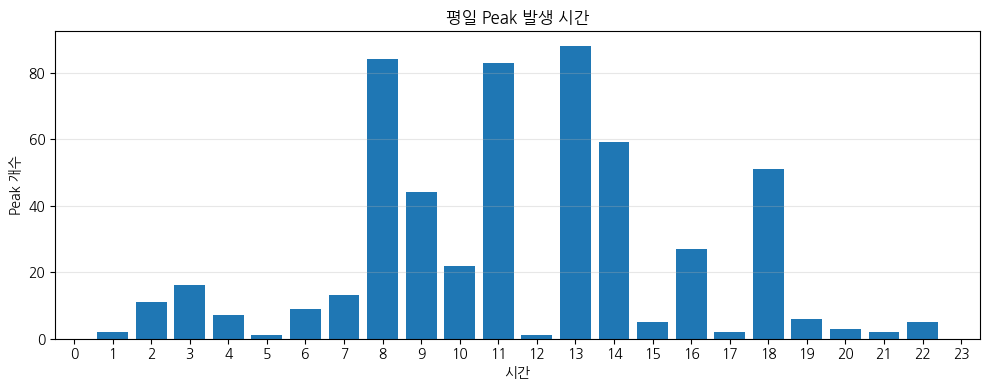

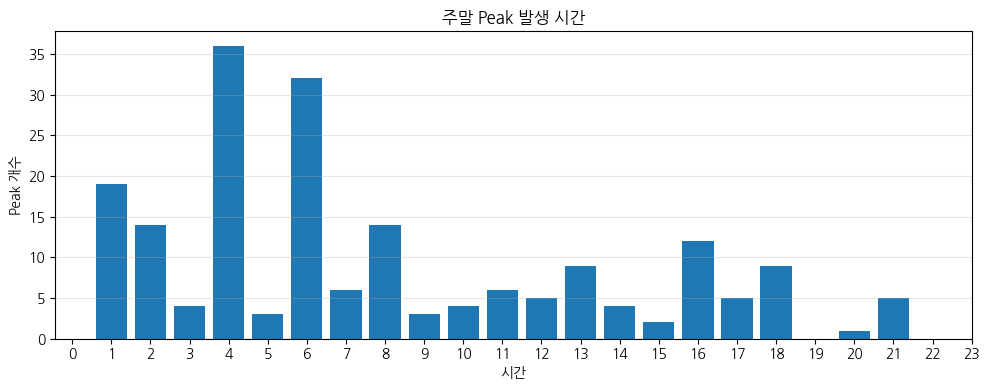

In [17]:
for day_type in ['평일', '주말']:
    
    temp = peak_hour_summary[
        peak_hour_summary['day_type'] == day_type
    ]
    
    plt.figure(figsize=(10, 4))
    
    plt.bar(
        temp['peak_hour'],
        temp['peak_count']
    )
    
    plt.title(
        f"{day_type} Peak 발생 시간"
    )
    
    plt.xlabel("시간")
    plt.ylabel("Peak 개수")
    
    plt.xticks(range(24))
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6. Peak 크기와 주요 변수의 관계

### 6-1. 산점도 (평일 / 주말)

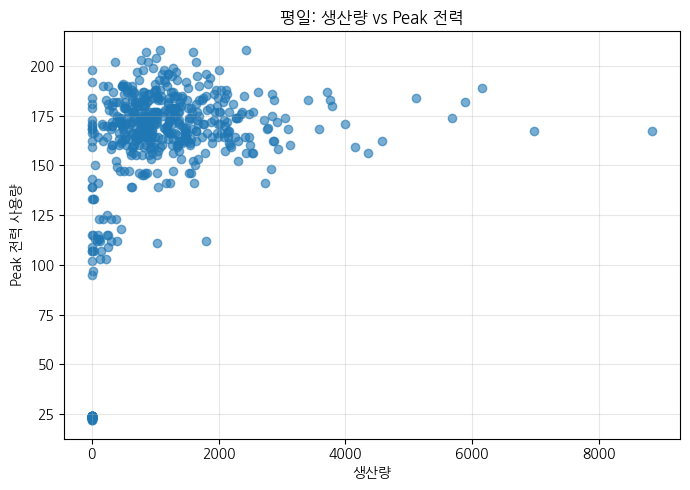

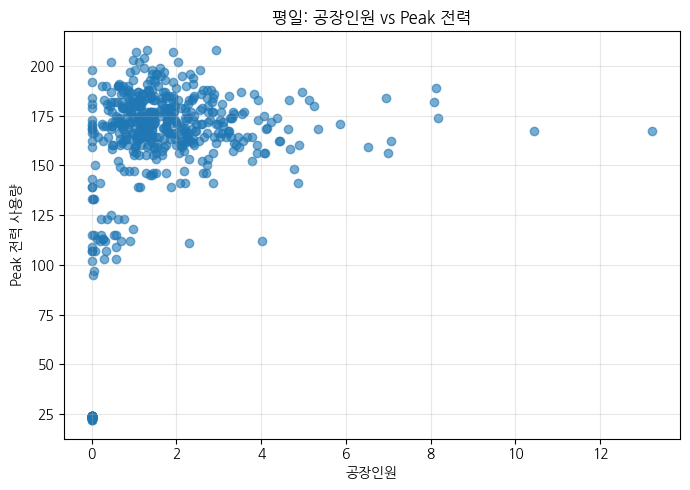

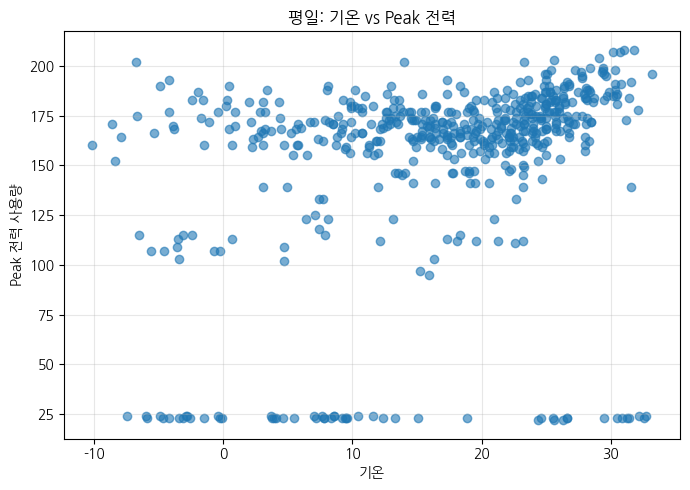

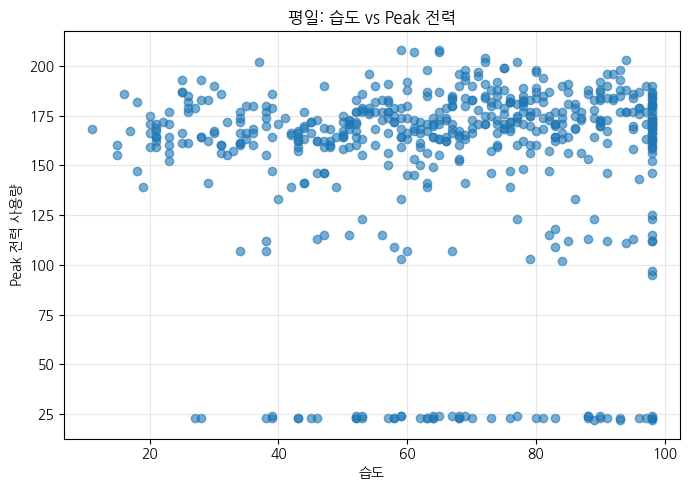

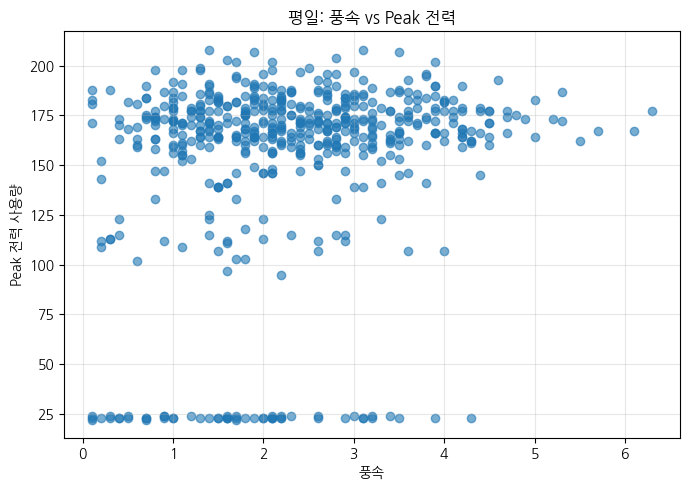

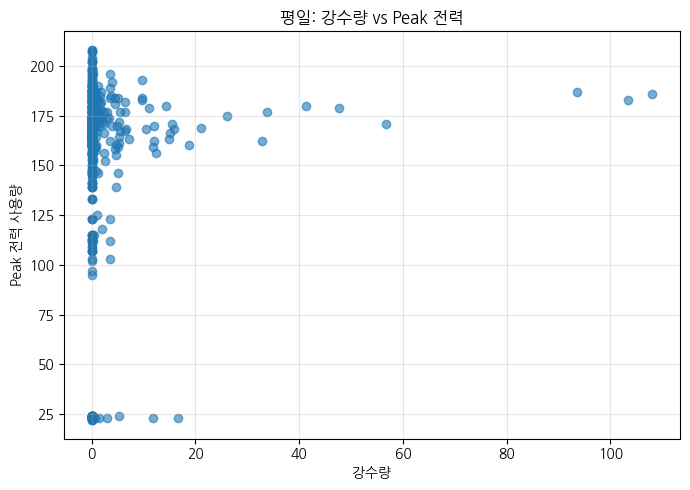

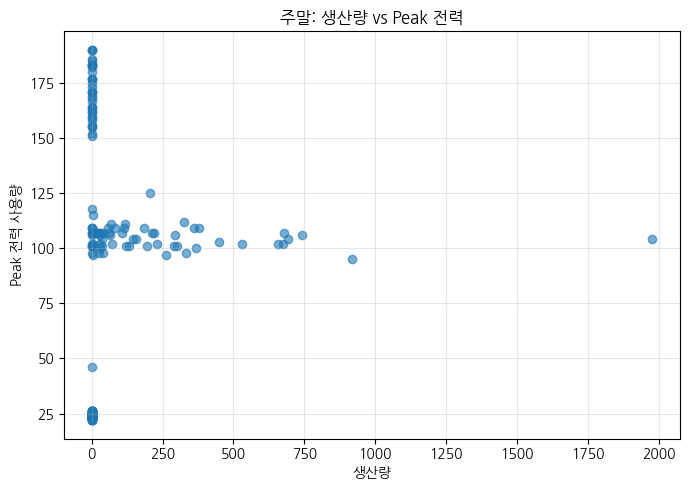

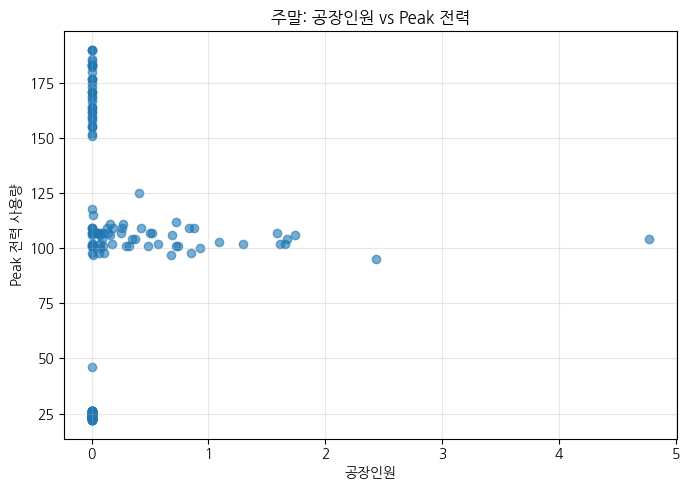

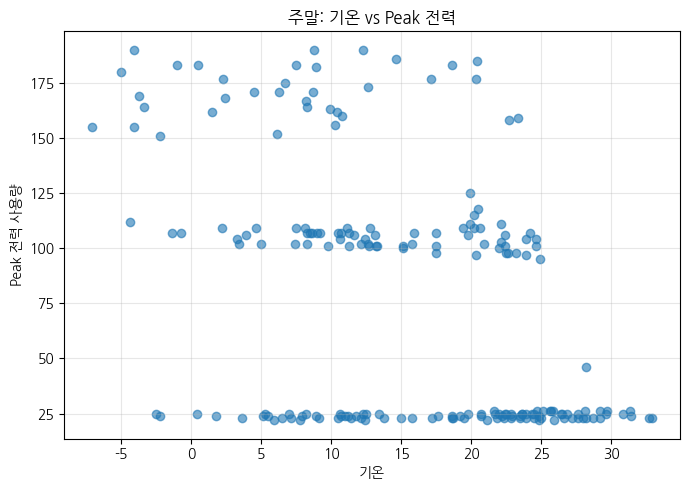

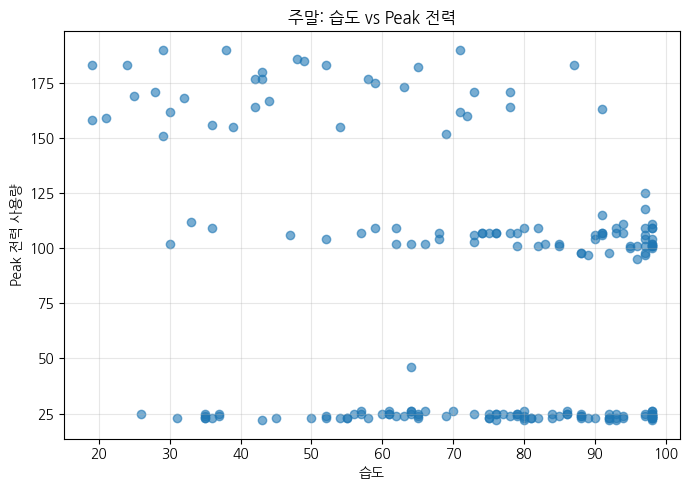

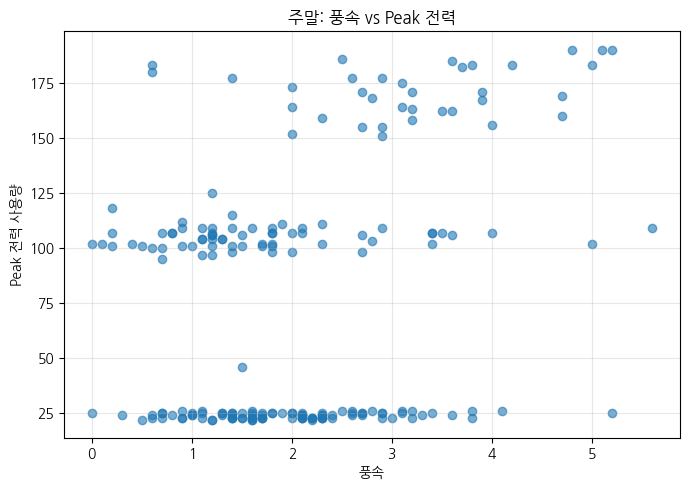

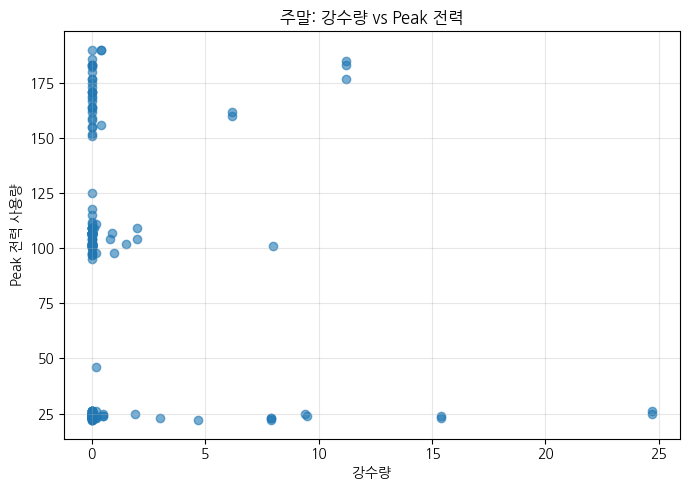

In [18]:
# 평일
candidate_features = [
    '생산량',
    '공장인원',
    '기온',
    '습도',
    '풍속',
    '강수량'
]

for feat in candidate_features:
    
    plt.figure(figsize=(7, 5))
    
    plt.scatter(
        weekday_peak[feat],
        weekday_peak['peak_value'],
        alpha=0.6
    )
    
    plt.xlabel(feat)
    plt.ylabel("Peak 전력 사용량")
    plt.title(
        f"평일: {feat} vs Peak 전력"
    )
    
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# 주말
for feat in candidate_features:
    
    plt.figure(figsize=(7, 5))
    
    plt.scatter(
        weekend_peak[feat],
        weekend_peak['peak_value'],
        alpha=0.6
    )
    
    plt.xlabel(feat)
    plt.ylabel("Peak 전력 사용량")
    plt.title(
        f"주말: {feat} vs Peak 전력"
    )
    
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### 6-2. 상관계수

In [19]:
corr_features = [
    'peak_value',
    '생산량',
    '공장인원',
    '기온',
    '습도',
    '풍속',
    '강수량',
    'peak_hour'
]

weekday_corr = (
    weekday_peak[corr_features]
    .corr()['peak_value']
    .sort_values(
        ascending=False
    )
)

weekend_corr = (
    weekend_peak[corr_features]
    .corr()['peak_value']
    .sort_values(
        ascending=False
    )
)

print("===== 평일 Peak 상관계수 =====")
display(
    weekday_corr.round(3)
)

print("\n===== 주말 Peak 상관계수 =====")
display(
    weekend_corr.round(3)
)

===== 평일 Peak 상관계수 =====


peak_value    1.000
생산량           0.408
공장인원          0.380
기온            0.310
peak_hour     0.300
풍속            0.203
강수량           0.068
습도           -0.022
Name: peak_value, dtype: float64


===== 주말 Peak 상관계수 =====


peak_value    1.000
풍속            0.297
생산량           0.151
공장인원          0.148
peak_hour     0.092
강수량          -0.057
습도           -0.273
기온           -0.460
Name: peak_value, dtype: float64

## 7. 시차(Lag) · 이동평균(Rolling) 변수 생성
Peak 직전의 상태가 Peak 크기에 영향을 주는지 보기 위해 생산량 · 공장인원 · 기상 변수의
- **Lag**: 1~4시간 전 값
- **Rolling**: 직전 3 · 6 · 24시간 평균 (현재 시점 제외)

을 만들어 Peak 데이터에 붙인다.

In [20]:
data = data.sort_values(
    'datetime'
).reset_index(drop=True)

base_features = [
    '생산량',
    '공장인원',
    '기온',
    '습도',
    '풍속',
    '강수량'
]

lags = [1, 2, 3, 4]   # 1~4시간 전 값

for feat in base_features:
    
    for lag in lags:
        
        data[
            f'{feat}_lag{lag}h'
        ] = (
            data[feat]
            .shift(lag)
        )

In [21]:
# 직전 3 · 6 · 24시간 이동평균 (shift(1): 현재 시점 제외)
rolling_windows = [3, 6, 24]

for feat in base_features:
    
    for window in rolling_windows:
        
        data[
            f'{feat}_roll{window}h_mean'
        ] = (
            data[feat]
            .shift(1)
            .rolling(window)
            .mean()
        )

In [22]:
# Lag · Rolling 변수를 Peak 데이터에 결합
lag_features = []

for feat in base_features:
    
    for lag in lags:
        lag_features.append(
            f'{feat}_lag{lag}h'
        )

rolling_features = []

for feat in base_features:
    
    for window in rolling_windows:
        rolling_features.append(
            f'{feat}_roll{window}h_mean'
        )

feature_cols_to_merge = (
    ['datetime']
    + lag_features
    + rolling_features
)

peak_model_df = peak_df.merge(
    data[feature_cols_to_merge],
    on='datetime',
    how='left'
)

print(
    "Peak 분석 데이터:",
    peak_model_df.shape
)

display(
    peak_model_df.head()
)

Peak 분석 데이터: (734, 76)


,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,...,기온_roll24h_mean,습도_roll3h_mean,습도_roll6h_mean,습도_roll24h_mean,풍속_roll3h_mean,풍속_roll6h_mean,풍속_roll24h_mean,강수량_roll3h_mean,강수량_roll6h_mean,강수량_roll24h_mean
0,20210101,4,108,105,106,108,107,0,-4.6,2.6,...,NaN,63.666667,NaN,NaN,2.233333,NaN,NaN,0.0,NaN,NaN
1,20210101,6,102,111,110,103,107,0,-5.6,1.5,...,NaN,60.666667,64.666667,NaN,2.433333,2.300000,NaN,0.0,0.0,NaN
2,20210102,4,108,105,106,108,107,0,-1.4,1.8,...,-0.845833,67.333333,63.666667,57.458333,1.166667,1.383333,1.870833,0.0,0.0,0.0
3,20210102,6,102,111,110,103,107,0,-0.7,2.1,...,-0.529167,73.333333,68.333333,58.375000,1.366667,1.316667,1.812500,0.0,0.0,0.0
4,20210103,1,24,27,24,24,25,0,-2.5,2.1,...,-0.233333,34.000000,32.166667,46.791667,2.933333,3.016667,2.441667,0.0,0.0,0.0


### 7-1. 시간대 · 월 주기 변수 (sin / cos)
Peak는 특정 시간대에 반복적으로 나타나므로, 시각과 월을 주기 변수로 넣어 **시간대 자체의 영향을 통제**한다.

In [23]:
# 시각(24시간 주기) · 월(12개월 주기)을 sin/cos로 변환
peak_model_df['hour_sin'] = np.sin(
    2 * np.pi *
    peak_model_df['peak_hour'] / 24
)

peak_model_df['hour_cos'] = np.cos(
    2 * np.pi *
    peak_model_df['peak_hour'] / 24
)

peak_model_df['month_sin'] = np.sin(
    2 * np.pi *
    peak_model_df['month'] / 12
)

peak_model_df['month_cos'] = np.cos(
    2 * np.pi *
    peak_model_df['month'] / 12
)

In [24]:
# 주기 변수가 포함된 평일 / 주말 Peak 데이터
weekday_peak = peak_model_df[
    peak_model_df['day_type'] == '평일'
].copy()

weekend_peak = peak_model_df[
    peak_model_df['day_type'] == '주말'
].copy()

print("===== 평일 Peak =====")
print("행 수:", len(weekday_peak))
print("hour_sin 존재:", 'hour_sin' in weekday_peak.columns)
print("hour_cos 존재:", 'hour_cos' in weekday_peak.columns)
print("month_sin 존재:", 'month_sin' in weekday_peak.columns)
print("month_cos 존재:", 'month_cos' in weekday_peak.columns)

print("\n===== 주말 Peak =====")
print("행 수:", len(weekend_peak))
print("hour_sin 존재:", 'hour_sin' in weekend_peak.columns)
print("hour_cos 존재:", 'hour_cos' in weekend_peak.columns)
print("month_sin 존재:", 'month_sin' in weekend_peak.columns)
print("month_cos 존재:", 'month_cos' in weekend_peak.columns)

===== 평일 Peak =====
행 수: 541
hour_sin 존재: True
hour_cos 존재: True
month_sin 존재: True
month_cos 존재: True

===== 주말 Peak =====
행 수: 193
hour_sin 존재: True
hour_cos 존재: True
month_sin 존재: True
month_cos 존재: True


## 8. 계절 · 근무구분별 대표 전력 패턴과 Peak

| 구분 | 정의 |
|---|---|
| 계절 | 겨울(~3/20) · 봄(3/21~6/20) · 여름(6/21~) |
| 근무구분 | 근무일 / 비근무일(주말 + 공휴일) |
| 분석 대상 | 근무일 중 **가동일**(하루 평균 ≥ 70kW), 비근무일 중 **저부하일**(평탄한 정지일 제외) |

- 근무일은 새벽(0~6시)의 평탄 구간을 제외하고 대표 곡선(평균)을 계산한다.
- 대표 곡선에서 Peak를 찾고, 그 시각에 실제로 Peak가 난 날짜의 비율을 함께 표시한다.

분석 대상 날짜 수 (계절 × 근무구분)


day_type,근무일,비근무일
season,,
겨울,38,10
봄,61,15
여름,56,11



분석 제외 날짜 수


excluded,근무일-저부하일,비근무일-가동일,비근무일-정지일(평탄)
season,,,
겨울,14,11,6
봄,2,3,11
여름,5,1,13


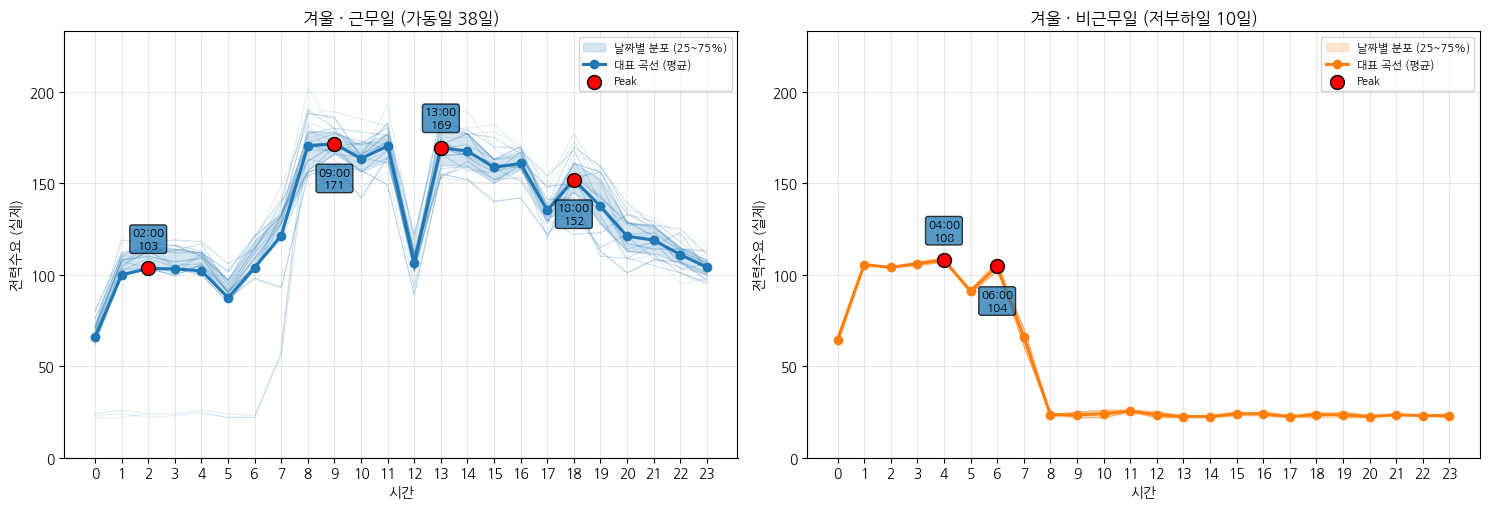

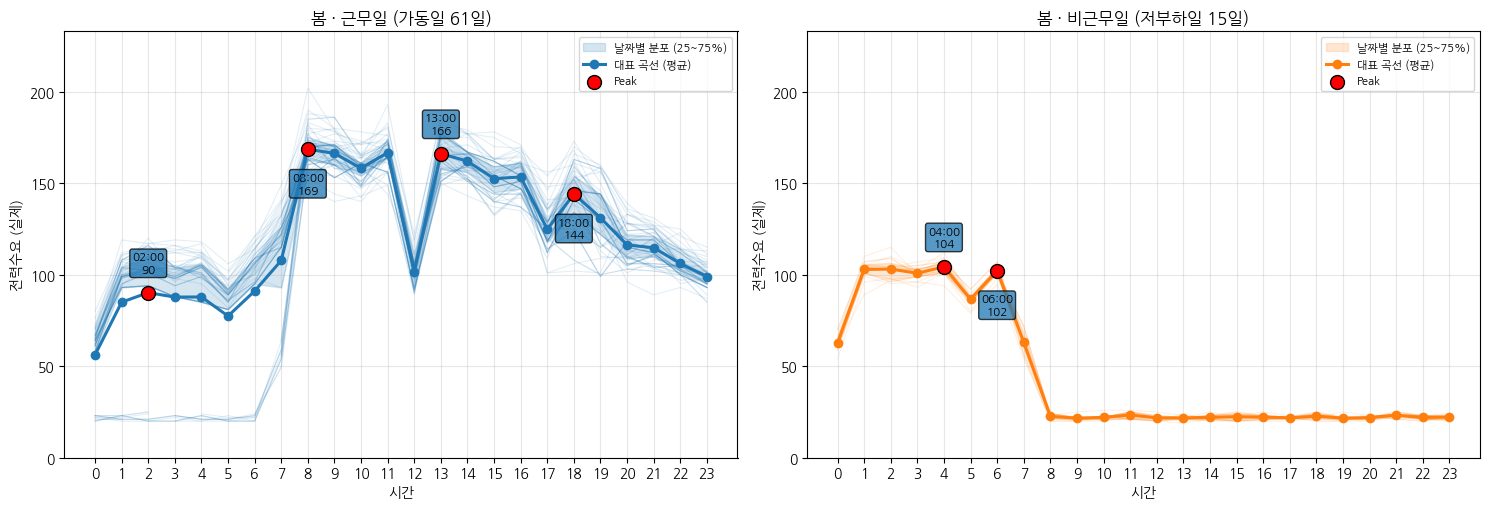

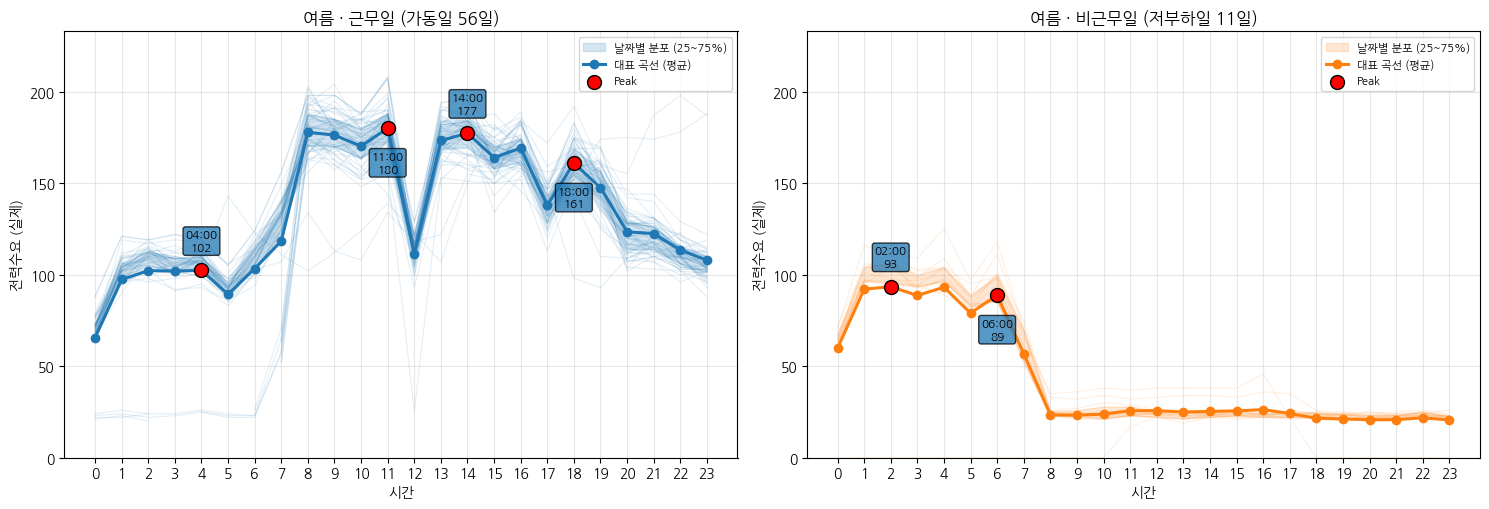

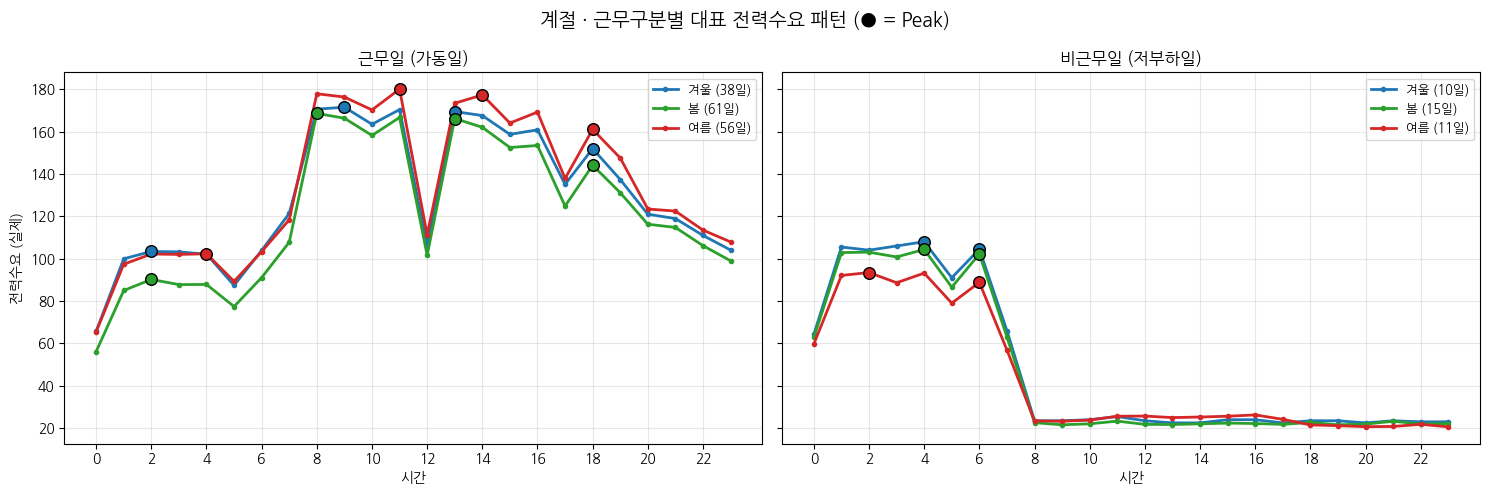


계절 · 근무구분별 대표 전력수요의 Peak 시간과 전력수요량


,계절,근무구분,부하 유형,날짜 수,Peak 순서,Peak 시간,Peak 전력수요,그 시각 Peak 발생 비율(%),하루 최대수요 중앙값
0,겨울,근무일,가동일,38,1,02:00,103.4,13,177.0
1,겨울,근무일,가동일,38,2,09:00,171.5,37,177.0
2,겨울,근무일,가동일,38,3,13:00,169.4,61,177.0
3,겨울,근무일,가동일,38,4,18:00,151.9,26,177.0
4,겨울,비근무일,저부하일,10,1,04:00,108.0,100,108.0
5,겨울,비근무일,저부하일,10,2,06:00,104.5,100,108.0
6,봄,근무일,가동일,61,1,02:00,90.2,3,173.0
7,봄,근무일,가동일,61,2,08:00,168.5,59,173.0
8,봄,근무일,가동일,61,3,13:00,166.1,69,173.0
9,봄,근무일,가동일,61,4,18:00,144.1,38,173.0


In [25]:
# ---- 설정 ----
VALUE_COL   = '평균'
SEASONS     = ['겨울', '봄', '여름']
DAY_TYPES   = ['근무일', '비근무일']
PROM_RATIO  = 0.08     # Peak prominence 비율
ACTIVE_MEAN = 70       # 하루 평균 전력이 이 값 이상이면 '가동일'
FLAT_RANGE  = 20       # 하루 (최대 - 최소)가 이 값 미만이면 '평탄'
MIN_DAYS    = 3        # 그룹별 최소 날짜 수
CURVE_STAT  = 'mean'   # 대표 곡선: 'mean' 또는 'median'
 
# 근무일 새벽 평탄 구간 제외 설정
EARLY_END     = 6      # 검사할 새벽 시간대: 0시 ~ EARLY_END시
FLAT_TOL      = 1.0    # 연속한 두 시각의 차이가 이 값 이하이면 '평탄'으로 간주
FLAT_MIN_LEN  = 3      # 평탄 구간이 최소 몇 시간 연속이어야 제외할지
 
# 근무구분별로 분석할 부하 유형과 그래프 색
TARGET = {'근무일': ('가동일', 'tab:blue'),
          '비근무일': ('저부하일', 'tab:orange')}
 
# 공휴일 목록 (데이터에 공휴일 컬럼이 없어 직접 입력, 2021-01-01 ~ 09-14)
HOLIDAYS = pd.to_datetime([
    '2021-01-01',                                   # 신정
    '2021-02-11', '2021-02-12', '2021-02-13',       # 설 연휴
    '2021-03-01',                                   # 삼일절
    '2021-05-05', '2021-05-19',                     # 어린이날, 부처님오신날
    '2021-06-06',                                   # 현충일
    '2021-08-15', '2021-08-16'                      # 광복절, 대체공휴일
]).date
 
 
def assign_season(ts):             # 겨울 ~3/20 / 봄 3/21~6/20 / 여름 6/21~
    md = (ts.month, ts.day)
    if md < (3, 21):
        return '겨울'
    if md < (6, 21):
        return '봄'
    return '여름'
 
 
def rep_curve(mat):
    return mat.mean() if CURVE_STAT == 'mean' else mat.median()
 
 
def find_curve_peaks(y):
    idx, _ = find_peaks(y, prominence=(y.max() - y.min()) * PROM_RATIO, distance=2)
    if len(idx) == 0:
        idx = np.array([int(np.argmax(y))])
    return idx
 
 
def mask_early_flat(row):
    """하루 곡선에서 새벽(0~EARLY_END시)의 평탄 구간을 NaN 처리"""
    v = row.values.astype(float).copy()
    h = 0
    while h < EARLY_END:
        j = h
        while j < EARLY_END and abs(v[j + 1] - v[j]) <= FLAT_TOL:
            j += 1
        if j - h + 1 >= FLAT_MIN_LEN:      # 평탄 구간이 충분히 길면 제외
            v[h:j + 1] = np.nan
        h = j + 1 if j > h else h + 1
    return pd.Series(v, index=row.index)
 
 
# =========================================================
# 1. 데이터 준비
# =========================================================
pred = pd.read_excel(file_path)
pred['datetime'] = pd.to_datetime(pred['datetime'])
pred = pred.sort_values('datetime').drop_duplicates('datetime').reset_index(drop=True)
pred = pred[pred['datetime'].dt.month <= 9].copy()
 
pred['date'] = pred['datetime'].dt.date
pred['hour'] = pred['datetime'].dt.hour
pred = pred[pred.groupby('date')['hour'].transform('nunique') == 24].copy()
 
# 비근무일 = 주말 + 공휴일
is_off = (pred['datetime'].dt.weekday >= 5) | (pred['date'].isin(HOLIDAYS))
pred['day_type'] = np.where(is_off, '비근무일', '근무일')
pred['season'] = pred['datetime'].map(assign_season)
 
curves = pred.pivot(index='date', columns='hour', values=VALUE_COL)   # 날짜 × 24시간
day_info = pred.groupby('date')[['season', 'day_type']].first().loc[curves.index]
day_info['regime'] = np.where(curves.mean(axis=1) >= ACTIVE_MEAN, '가동일', '저부하일')
 
# 하루 종일 평탄한 날(완전 정지일) 표시
day_info['flat'] = (curves.max(axis=1) - curves.min(axis=1)) < FLAT_RANGE
 
# 분석 대상: 근무일-가동일, 비근무일-저부하일(평탄한 정지일 제외)
day_info['target'] = [
    (t == '근무일' and r == '가동일') or
    (t == '비근무일' and r == '저부하일' and not f)
    for t, r, f in zip(day_info['day_type'], day_info['regime'], day_info['flat'])
]
 
day_info['excluded'] = ''
day_info.loc[(day_info['day_type'] == '근무일') & (day_info['regime'] == '저부하일'),
             'excluded'] = '근무일-저부하일'
day_info.loc[(day_info['day_type'] == '비근무일') & (day_info['regime'] == '가동일'),
             'excluded'] = '비근무일-가동일'
day_info.loc[(day_info['day_type'] == '비근무일') & (day_info['regime'] == '저부하일') &
             day_info['flat'], 'excluded'] = '비근무일-정지일(평탄)'
 
# 근무일만 새벽 평탄 구간을 NaN 처리한 곡선 (대표 곡선 계산용)
curves_clean = curves.copy()
workdays = day_info.index[day_info['day_type'] == '근무일']
curves_clean.loc[workdays] = curves.loc[workdays].apply(mask_early_flat, axis=1)
 
print("분석 대상 날짜 수 (계절 × 근무구분)")
display(day_info[day_info['target']].groupby(['season', 'day_type']).size().unstack())
print("\n분석 제외 날짜 수")
display(pd.crosstab(day_info.loc[~day_info['target'], 'season'],
                    day_info.loc[~day_info['target'], 'excluded']))
 
# 날짜별 Peak 시각 (4절과 같은 방식, 3개 초과 시 큰 3개)
daily_peak_hours = {}
for d, day_df in pred[pred['date'].isin(day_info.index[day_info['target']])].groupby('date'):
    pk = detect_daily_peaks(day_df, value_col=VALUE_COL,
                            prominence_ratio=PROM_RATIO, distance=2)
    if len(pk) > 3:
        pk = pk.sort_values(VALUE_COL, ascending=False).head(3)
    daily_peak_hours[d] = pk['hour'].tolist()
 
 
# =========================================================
# 2. 그룹별 대표 곡선 → Peak → 그래프 (계절당 그림 1장)
# =========================================================
summary_rows = []
reps = {}
 
for season in SEASONS:
 
    fig, axes = plt.subplots(1, len(DAY_TYPES), figsize=(15, 5.2))
 
    for ax, day_type in zip(axes, DAY_TYPES):
 
        regime, col = TARGET[day_type]
        dates = day_info.index[
            (day_info['season'] == season) &
            (day_info['day_type'] == day_type) &
            (day_info['target'])
        ]
 
        ax.set_title(f'{season} · {day_type} ({regime} {len(dates)}일)')
        ax.set_xticks(range(24))
        ax.set_xlabel('시간')
        ax.set_ylabel('전력수요 (실제)')
        ax.set_ylim(0, curves.values.max() * 1.12)
        ax.grid(alpha=0.3)
 
        if len(dates) < MIN_DAYS:
            ax.text(0.5, 0.5, f'표본 부족 ({len(dates)}일)', ha='center',
                    va='center', transform=ax.transAxes)
            continue
 
        mat = curves_clean.loc[dates]                      # 새벽 평탄 구간 제외된 곡선
        y = rep_curve(mat)                                 # NaN은 자동으로 건너뛰고 계산
        y = y.interpolate(limit_direction='both').values   # 모든 날짜가 NaN인 시각이 있을 때만 보간
        flat = (y.max() - y.min()) < FLAT_RANGE
        peak_idx = np.array([], dtype=int) if flat else find_curve_peaks(y)
        reps[(season, day_type)] = (y, peak_idx, len(dates))
 
        # ---- 그래프 ----
        for _, row in mat.iterrows():
            ax.plot(range(24), row.values, color=col, alpha=0.12, linewidth=0.8)
        ax.fill_between(range(24), mat.quantile(0.25).values,
                        mat.quantile(0.75).values, color=col, alpha=0.18,
                        label='날짜별 분포 (25~75%)')
        ax.plot(range(24), y, marker='o', linewidth=2.2, color=col,
                label=f'대표 곡선 ({"평균" if CURVE_STAT == "mean" else "중앙값"})')
        ax.scatter(peak_idx, y[peak_idx], s=100, color='red',
                   edgecolor='black', zorder=5, label='Peak')
 
        for order, idx in enumerate(peak_idx, start=1):
            ax.annotate(f'{idx:02d}:00\n{y[idx]:.0f}', xy=(idx, y[idx]),
                        xytext=(0, 14 if order % 2 else -32),
                        textcoords='offset points', ha='center', fontsize=8.5,
                        bbox=dict(boxstyle='round,pad=0.2', alpha=0.75))
        if flat:
            ax.text(0.5, 0.6, f'평탄 (약 {y.mean():.0f}) · Peak 없음',
                    ha='center', transform=ax.transAxes, color=col)
        ax.legend(loc='upper right', fontsize=8)
 
        # ---- 요약표 ----
        cnt = np.zeros(24)
        for d in dates:
            for h in daily_peak_hours[d]:
                cnt[h] += 1
        rate = cnt / len(dates) * 100
        day_max = mat.max(axis=1)
 
        if flat:
            summary_rows.append({
                '계절': season, '근무구분': day_type, '부하 유형': regime,
                '날짜 수': len(dates), 'Peak 순서': '-', 'Peak 시간': '없음(평탄)',
                'Peak 전력수요': round(y.mean(), 1),
                '그 시각 Peak 발생 비율(%)': np.nan,
                '하루 최대수요 중앙값': round(day_max.median(), 1)
            })
        for order, idx in enumerate(peak_idx, start=1):
            summary_rows.append({
                '계절': season, '근무구분': day_type, '부하 유형': regime,
                '날짜 수': len(dates), 'Peak 순서': order,
                'Peak 시간': f'{idx:02d}:00',
                'Peak 전력수요': round(y[idx], 1),
                '그 시각 Peak 발생 비율(%)': round(rate[idx]),
                '하루 최대수요 중앙값': round(day_max.median(), 1)
            })
 
    plt.tight_layout()
    plt.show()
 
 
# =========================================================
# 3. 종합 그래프 (계절별 대표 곡선 비교)
# =========================================================
fig, axes = plt.subplots(1, len(DAY_TYPES), figsize=(15, 5), sharey=True)
season_colors = {'겨울': 'tab:blue', '봄': 'tab:green', '여름': 'tab:red'}
 
for ax, day_type in zip(axes, DAY_TYPES):
    for season in SEASONS:
        if (season, day_type) not in reps:
            continue
        y, idx, n = reps[(season, day_type)]
        ax.plot(range(24), y, marker='o', markersize=3, linewidth=2,
                color=season_colors[season], label=f'{season} ({n}일)')
        ax.scatter(idx, y[idx], s=70, color=season_colors[season],
                   edgecolor='black', zorder=5)
    ax.set_title(f'{day_type} ({TARGET[day_type][0]})')
    ax.set_xticks(range(0, 24, 2))
    ax.set_xlabel('시간')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
 
axes[0].set_ylabel('전력수요 (실제)')
plt.suptitle('계절 · 근무구분별 대표 전력수요 패턴 (● = Peak)', fontsize=14)
plt.tight_layout()
plt.show()
 
 
# =========================================================
# 4. 최종 요약표
# =========================================================
representative_peak_summary_df = pd.DataFrame(summary_rows)
 
print("\n" + "=" * 80)
print("계절 · 근무구분별 대표 전력수요의 Peak 시간과 전력수요량")
print("=" * 80)
 
display(representative_peak_summary_df)

## 9. OLS 회귀 — Peak 크기에 영향을 주는 변수
- 입력 변수는 표준화(StandardScaler)해 계수 크기를 비교할 수 있게 한다.
- 같은 날의 Peak끼리는 독립이 아니므로 **날짜 단위 클러스터 표준오차**를 사용한다.

In [26]:
# 표준화 OLS 회귀 (날짜 단위 클러스터 표준오차)
def run_ols(
    df_input,
    target='peak_value',
    features=None
):
    
    temp = df_input[
        [target] + features + ['date']
    ].dropna().copy()
    
    X = temp[features]
    y = temp[target]
    
    # 표준화
    scaler = StandardScaler()
    
    X_scaled = scaler.fit_transform(X)
    
    X_scaled = pd.DataFrame(
        X_scaled,
        columns=features,
        index=X.index
    )
    
    X_scaled = sm.add_constant(
        X_scaled
    )
    
    model = sm.OLS(
        y,
        X_scaled
    ).fit(
        cov_type='cluster',
        cov_kwds={
            'groups': temp['date']
        }
    )
    
    return model

### 9-1. 현재값 기반 회귀

In [27]:
# Peak 시점의 현재값 + 주기 변수
current_features = [
    '생산량',
    '공장인원',
    '기온',
    '습도',
    '풍속',
    '강수량',
    'hour_sin',
    'hour_cos',
    'month_sin',
    'month_cos'
]

weekday_model_current = run_ols(
    weekday_peak,
    target='peak_value',
    features=current_features
)

weekend_model_current = run_ols(
    weekend_peak,
    target='peak_value',
    features=current_features
)

print("===== 평일 현재값 회귀 =====")
print(
    weekday_model_current.summary()
)

print("\n===== 주말 현재값 회귀 =====")
print(
    weekend_model_current.summary()
)

===== 평일 현재값 회귀 =====
                            OLS Regression Results                            
Dep. Variable:             peak_value   R-squared:                       0.379
Model:                            OLS   Adj. R-squared:                  0.368
Method:                 Least Squares   F-statistic:                     23.35
Date:                Wed, 30 Sep 2026   Prob (F-statistic):           7.84e-28
Time:                        17:53:58   Log-Likelihood:                -2725.3
No. Observations:                 541   AIC:                             5473.
Df Residuals:                     530   BIC:                             5520.
Df Model:                          10                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        153.7172      2.5

In [28]:
# 회귀계수 정리 (p-value 오름차순)
def regression_table(model):
    
    result = pd.DataFrame({
        'coef': model.params,
        'p_value': model.pvalues,
        'std_error': model.bse
    })
    
    result = result.sort_values(
        'p_value'
    )
    
    return result


print("===== 평일 =====")

display(
    regression_table(
        weekday_model_current
    ).round(4)
)


print("===== 주말 =====")

display(
    regression_table(
        weekend_model_current
    ).round(4)
)

===== 평일 =====


,coef,p_value,std_error
const,153.7172,0.0000,2.5524
hour_cos,-15.4283,0.0000,1.8879
생산량,62.6601,0.0003,17.4099
month_cos,-14.0748,0.0024,4.6359
공장인원,-51.1297,0.0025,16.9442
hour_sin,-4.2512,0.0173,1.7862
풍속,3.4175,0.1983,2.6568
기온,-5.9563,0.3890,6.9140
month_sin,-2.1185,0.6801,5.1374
강수량,0.3171,0.7661,1.0662


===== 주말 =====


,coef,p_value,std_error
const,78.1036,0.0000,5.5673
hour_cos,-14.6447,0.0045,5.1594
풍속,11.9026,0.0484,6.0296
기온,-27.4287,0.0516,14.0887
습도,8.2017,0.4232,10.2419
생산량,42.9379,0.5542,72.6013
hour_sin,-1.8452,0.6491,4.0554
공장인원,-32.4327,0.6509,71.6805
강수량,-2.8305,0.6511,6.2588
month_cos,-0.7360,0.9498,11.6954


### 9-2. Peak 직전 정보(Lag · Rolling) 기반 회귀

In [29]:
# Peak 직전 정보 변수: Lag + Rolling + 주기 변수
past_features = (
    lag_features
    + rolling_features
    + [
        'hour_sin',
        'hour_cos',
        'month_sin',
        'month_cos'
    ]
)

print(
    "과거정보 변수 개수:",
    len(past_features)
)

과거정보 변수 개수: 46


In [30]:
# 평일
weekday_model_past = run_ols(
    weekday_peak,
    target='peak_value',
    features=past_features
)

print(
    weekday_model_past.summary()
)

display(
    regression_table(
        weekday_model_past
    ).round(4)
)

# 주말
weekend_model_past = run_ols(
    weekend_peak,
    target='peak_value',
    features=past_features
)

print(
    weekend_model_past.summary()
)

display(
    regression_table(
        weekend_model_past
    ).round(4)
)

                            OLS Regression Results                            
Dep. Variable:             peak_value   R-squared:                       0.431
Model:                            OLS   Adj. R-squared:                  0.386
Method:                 Least Squares   F-statistic:                     9.309
Date:                Wed, 30 Sep 2026   Prob (F-statistic):           6.28e-27
Time:                        17:53:58   Log-Likelihood:                -2691.7
No. Observations:                 539   AIC:                             5465.
Df Residuals:                     498   BIC:                             5641.
Df Model:                          40                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               153.8905      2.48

/tmp/ipykernel_445/1594903862.py:32: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit(
/home/kampuser/.local/lib/python3.11/site-packages/statsmodels/base/model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 46, but rank is 40
  res = self.wald_test(


,coef,p_value,std_error
const,153.8905,0.0000,2.4895
hour_cos,-19.6115,0.0000,2.1099
풍속_roll24h_mean,10.0610,0.0111,3.9636
month_cos,-8.6356,0.0758,4.8631
공장인원_roll6h_mean,24.1879,0.0989,14.6564
풍속_lag2h,-5.1000,0.1073,3.1668
기온_roll24h_mean,19.0847,0.1185,12.2265
생산량_lag3h,-12.3095,0.1469,8.4856
공장인원_lag3h,10.8885,0.1965,8.4294
공장인원_lag1h,-7.8252,0.2072,6.2046


                            OLS Regression Results                            
Dep. Variable:             peak_value   R-squared:                       0.649
Model:                            OLS   Adj. R-squared:                  0.556
Method:                 Least Squares   F-statistic:                     26.67
Date:                Wed, 30 Sep 2026   Prob (F-statistic):           2.79e-30
Time:                        17:53:58   Log-Likelihood:                -953.14
No. Observations:                 193   AIC:                             1988.
Df Residuals:                     152   BIC:                             2122.
Df Model:                          40                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                78.1036      4.36

/tmp/ipykernel_445/1594903862.py:32: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit(
/home/kampuser/.local/lib/python3.11/site-packages/statsmodels/base/model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 46, but rank is 40
  res = self.wald_test(


,coef,p_value,std_error
const,78.1036,0.0000,4.3650
생산량_roll24h_mean,23.0843,0.0010,7.0143
hour_cos,-16.2479,0.0024,5.3510
풍속_roll24h_mean,20.1740,0.0089,7.7087
습도_lag1h,-50.3593,0.0219,21.9775
강수량_roll24h_mean,-6.0645,0.0485,3.0744
hour_sin,-11.8115,0.0541,6.1328
기온_lag1h,-97.3156,0.0562,50.9588
습도_roll24h_mean,23.3325,0.0576,12.2873
생산량_lag3h,51.2531,0.1079,31.8782


### 9-3. 모델 설명력 비교 (R² · Adj. R²)

In [31]:
model_summary = pd.DataFrame({
    '구분': [
        '평일 현재값',
        '주말 현재값',
        '평일 과거정보',
        '주말 과거정보'
    ],
    
    'R_squared': [
        weekday_model_current.rsquared,
        weekend_model_current.rsquared,
        weekday_model_past.rsquared,
        weekend_model_past.rsquared
    ],
    
    'Adj_R_squared': [
        weekday_model_current.rsquared_adj,
        weekend_model_current.rsquared_adj,
        weekday_model_past.rsquared_adj,
        weekend_model_past.rsquared_adj
    ]
})

display(
    model_summary.round(4)
)

,구분,R_squared,Adj_R_squared
0,평일 현재값,0.3793,0.3676
1,주말 현재값,0.3332,0.2966
2,평일 과거정보,0.4313,0.3857
3,주말 과거정보,0.6487,0.5563


## 10. 비선형 관계 분석 — XGBoost 회귀
현재값 + Lag + Rolling + 주기 변수로 Peak 크기를 예측한다.
(아래 성능은 **학습 데이터에 대한 적합도**이며, 목적은 예측이 아니라 SHAP 해석이다.)

In [32]:
# 현재값 + Lag + Rolling + 주기 변수
xgb_features = (
    base_features
    + lag_features
    + rolling_features
    + [
        'hour_sin',
        'hour_cos',
        'month_sin',
        'month_cos'
    ]
)

print(
    "XGBoost 변수 개수:",
    len(xgb_features)
)

XGBoost 변수 개수: 52


In [33]:
def train_xgb_regressor(
    df_input,
    features,
    target='peak_value'
):
    
    temp = df_input[
        [target] + features
    ].dropna()
    
    X = temp[features]
    y = temp[target]
    
    model = XGBRegressor(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(
        X,
        y
    )
    
    return model, X, y

In [34]:
# 평일 XGBoost (학습 데이터 적합도)
weekday_xgb, X_weekday, y_weekday = (
    train_xgb_regressor(
        weekday_peak,
        xgb_features
    )
)

weekday_pred = (
    weekday_xgb.predict(
        X_weekday
    )
)

print(
    "평일 R²:",
    round(
        r2_score(
            y_weekday,
            weekday_pred
        ),
        4
    )
)

print(
    "평일 MAE:",
    round(
        mean_absolute_error(
            y_weekday,
            weekday_pred
        ),
        4
    )
)

print(
    "평일 RMSE:",
    round(
        np.sqrt(
            mean_squared_error(
                y_weekday,
                weekday_pred
            )
        ),
        4
    )
)

평일 R²: 0.9982
평일 MAE: 1.5305
평일 RMSE: 2.0282


In [35]:
# 주말 XGBoost (학습 데이터 적합도)
weekend_xgb, X_weekend, y_weekend = (
    train_xgb_regressor(
        weekend_peak,
        xgb_features
    )
)

weekend_pred = (
    weekend_xgb.predict(
        X_weekend
    )
)

print(
    "주말 R²:",
    round(
        r2_score(
            y_weekend,
            weekend_pred
        ),
        4
    )
)

print(
    "주말 MAE:",
    round(
        mean_absolute_error(
            y_weekend,
            weekend_pred
        ),
        4
    )
)

print(
    "주말 RMSE:",
    round(
        np.sqrt(
            mean_squared_error(
                y_weekend,
                weekend_pred
            )
        ),
        4
    )
)

주말 R²: 0.9998
주말 MAE: 0.6417
주말 RMSE: 0.8849


### 10-1. 예측값 vs 실제 Peak

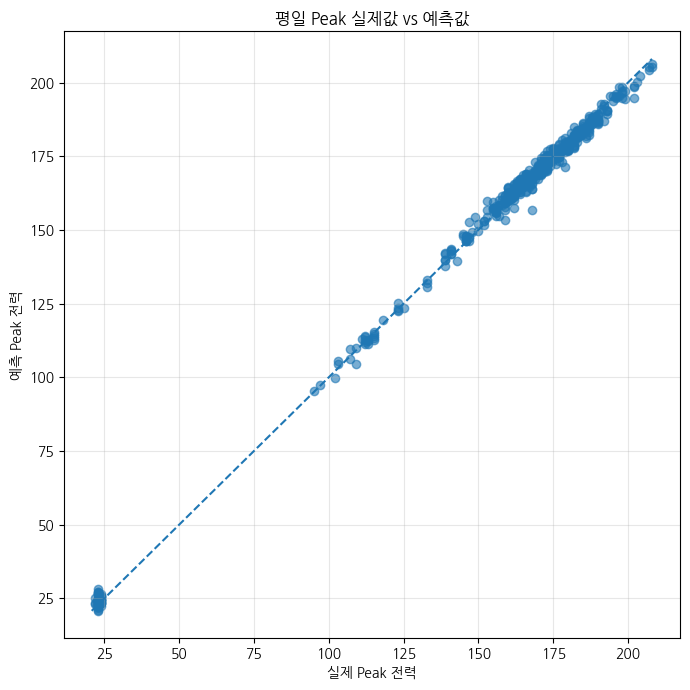

In [36]:
# 평일
plt.figure(figsize=(7, 7))

plt.scatter(
    y_weekday,
    weekday_pred,
    alpha=0.6
)

min_val = min(
    y_weekday.min(),
    weekday_pred.min()
)

max_val = max(
    y_weekday.max(),
    weekday_pred.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel("실제 Peak 전력")
plt.ylabel("예측 Peak 전력")

plt.title(
    "평일 Peak 실제값 vs 예측값"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

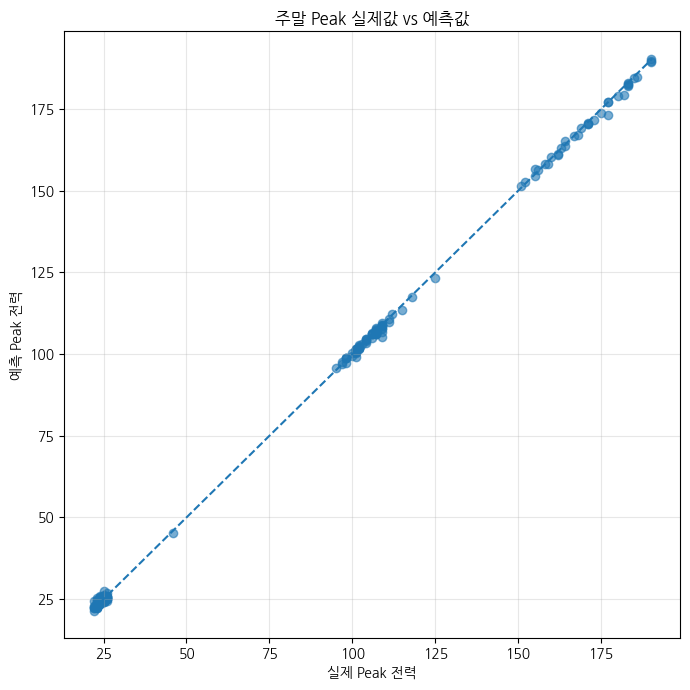

In [37]:
# 주말
plt.figure(figsize=(7, 7))

plt.scatter(
    y_weekend,
    weekend_pred,
    alpha=0.6
)

min_val = min(
    y_weekend.min(),
    weekend_pred.min()
)

max_val = max(
    y_weekend.max(),
    weekend_pred.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel("실제 Peak 전력")
plt.ylabel("예측 Peak 전력")

plt.title(
    "주말 Peak 실제값 vs 예측값"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. SHAP 기반 Peak 영향 변수

### 11-1. 변수별 평균 |SHAP| 중요도

In [38]:
# 평일
weekday_explainer = shap.TreeExplainer(
    weekday_xgb
)

weekday_shap = (
    weekday_explainer(
        X_weekday
    )
)

weekday_shap_importance = (
    pd.DataFrame({
        'feature': X_weekday.columns,
        'mean_abs_shap': np.abs(
            weekday_shap.values
        ).mean(axis=0)
    })
    .sort_values(
        'mean_abs_shap',
        ascending=False
    )
)

display(
    weekday_shap_importance.head(20)
)

,feature,mean_abs_shap
0,생산량,17.303436
49,hour_cos,6.790089
1,공장인원,2.784499
51,month_cos,2.770962
48,hour_sin,2.594755
50,month_sin,1.951728
38,기온_roll24h_mean,1.614968
30,생산량_roll3h_mean,1.259125
44,풍속_roll24h_mean,1.199325
32,생산량_roll24h_mean,0.994060


In [39]:
# 주말
weekend_explainer = shap.TreeExplainer(
    weekend_xgb
)

weekend_shap = (
    weekend_explainer(
        X_weekend
    )
)

weekend_shap_importance = (
    pd.DataFrame({
        'feature': X_weekend.columns,
        'mean_abs_shap': np.abs(
            weekend_shap.values
        ).mean(axis=0)
    })
    .sort_values(
        'mean_abs_shap',
        ascending=False
    )
)

display(
    weekend_shap_importance.head(20)
)

,feature,mean_abs_shap
31,생산량_roll6h_mean,9.415934
51,month_cos,9.024217
50,month_sin,7.491053
32,생산량_roll24h_mean,7.240422
49,hour_cos,7.131061
44,풍속_roll24h_mean,6.845703
41,습도_roll24h_mean,3.669983
15,기온_lag2h,3.002333
2,기온,2.507488
35,공장인원_roll24h_mean,2.352965


### 11-2. SHAP summary plot

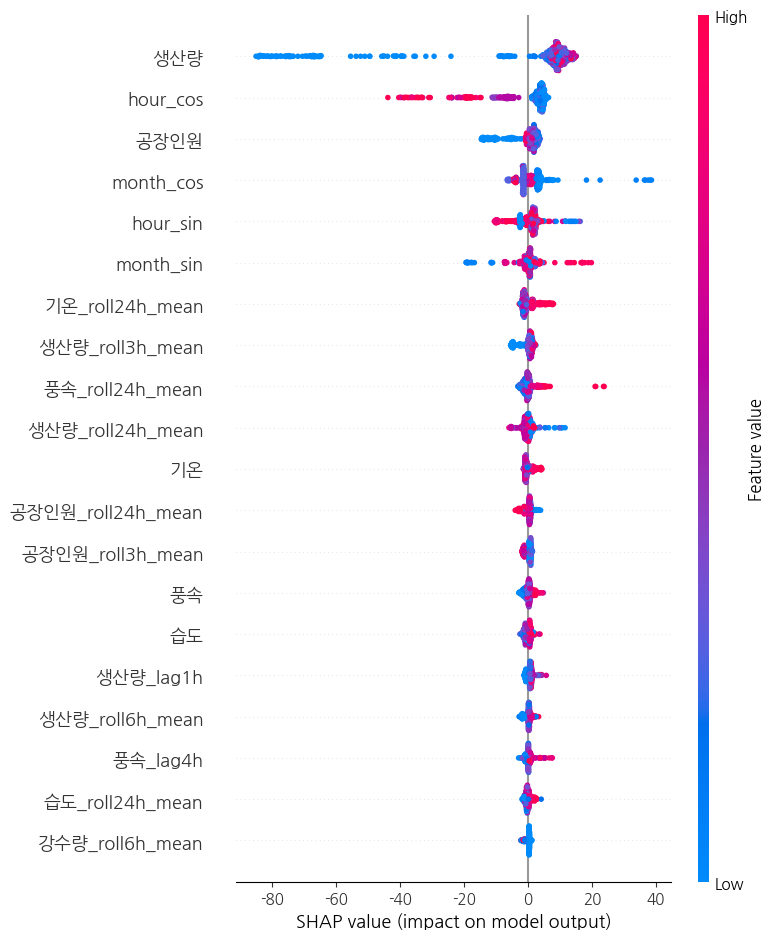

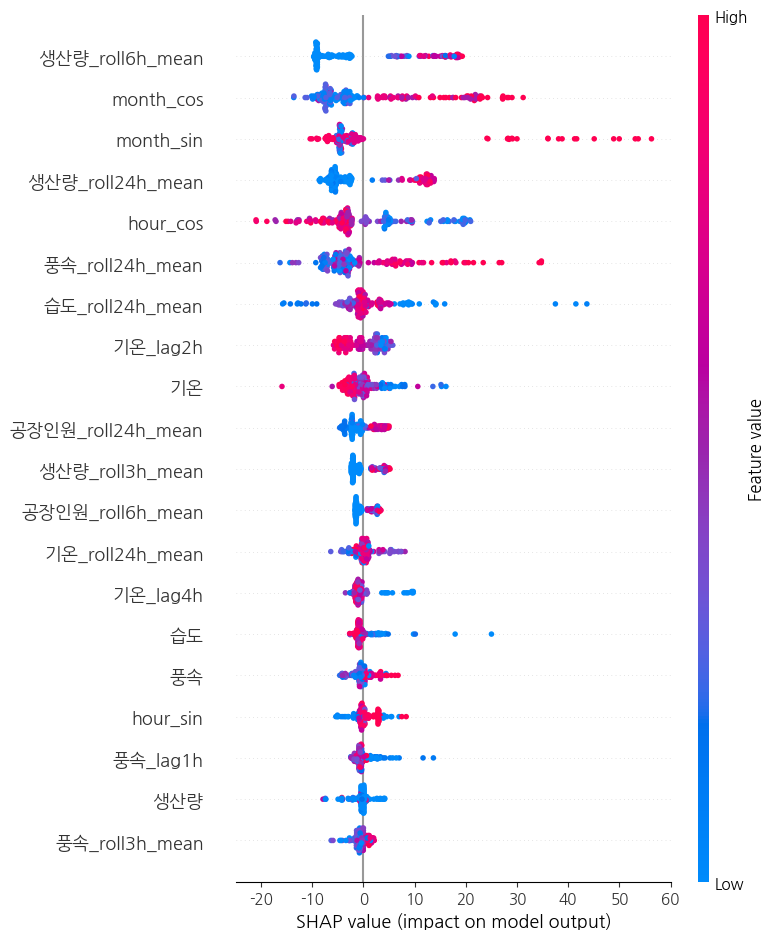

In [40]:
# 평일
shap.summary_plot(
    weekday_shap.values,
    X_weekday,
    max_display=20
)

# 주말
shap.summary_plot(
    weekend_shap.values,
    X_weekend,
    max_display=20
)

### 11-3. 평일 vs 주말 변수 중요도 비교

In [41]:
# 평일 / 주말 SHAP 중요도 병합 (difference = 평일 - 주말)
weekday_imp = (
    weekday_shap_importance
    .rename(
        columns={
            'mean_abs_shap':
            'weekday_shap'
        }
    )
)

weekend_imp = (
    weekend_shap_importance
    .rename(
        columns={
            'mean_abs_shap':
            'weekend_shap'
        }
    )
)

comparison = pd.merge(
    weekday_imp,
    weekend_imp,
    on='feature',
    how='outer'
).fillna(0)

comparison['difference'] = (
    comparison['weekday_shap']
    -
    comparison['weekend_shap']
)

comparison = comparison.sort_values(
    'weekday_shap',
    ascending=False
)

display(
    comparison.head(30).round(4)
)

,feature,weekday_shap,weekend_shap,difference
28,생산량,17.3034,0.9917,16.311701
0,hour_cos,6.7901,7.1311,-0.341000
12,공장인원,2.7845,0.2040,2.580500
2,month_cos,2.7710,9.0242,-6.253300
1,hour_sin,2.5948,1.3251,1.269700
3,month_sin,1.9517,7.4911,-5.539300
25,기온_roll24h_mean,1.6150,1.4546,0.160400
34,생산량_roll3h_mean,1.2591,2.2409,-0.981700
49,풍속_roll24h_mean,1.1993,6.8457,-5.646400
33,생산량_roll24h_mean,0.9941,7.2404,-6.246400


### 11-4. 핵심 변수(생산량 · 인원 · 기상)만 보기

In [42]:
key_patterns = [
    '생산량',
    '공장인원',
    '기온',
    '습도',
    '풍속',
    '강수량'
]

key_comparison = comparison[
    comparison['feature'].apply(
        lambda x:
        any(
            pattern in x
            for pattern in key_patterns
        )
    )
].copy()

display(
    key_comparison.round(4)
)

,feature,weekday_shap,weekend_shap,difference
28,생산량,17.3034,0.9917,16.311701
12,공장인원,2.7845,0.2040,2.580500
25,기온_roll24h_mean,1.6150,1.4546,0.160400
34,생산량_roll3h_mean,1.2591,2.2409,-0.981700
49,풍속_roll24h_mean,1.1993,6.8457,-5.646400
33,생산량_roll24h_mean,0.9941,7.2404,-6.246400
20,기온,0.9217,2.5075,-1.585800
17,공장인원_roll24h_mean,0.9058,2.3530,-1.447100
18,공장인원_roll3h_mean,0.8321,0.1044,0.727700
44,풍속,0.8237,1.3557,-0.532000


### 11-5. 생산량 Lag별 영향도

In [43]:
# 변수의 lag1~4 SHAP 중요도를 한 표로
def make_lag_summary(
    importance_df,
    variable
):
    
    rows = []
    
    for lag in [1, 2, 3, 4]:
        
        feature_name = (
            f'{variable}_lag{lag}h'
        )
        
        match = importance_df[
            importance_df['feature']
            == feature_name
        ]
        
        if len(match) > 0:
            
            rows.append({
                'lag': lag,
                'shap': match[
                    'mean_abs_shap'
                ].iloc[0]
            })
    
    return pd.DataFrame(rows)

In [44]:
# 평일
weekday_production_lag = make_lag_summary(
    weekday_shap_importance,
    '생산량'
)

display(
    weekday_production_lag
)

# 주말
weekend_production_lag = make_lag_summary(
    weekend_shap_importance,
    '생산량'
)

display(
    weekend_production_lag
)

,lag,shap
0,1,0.734046
1,2,0.305825
2,3,0.180707
3,4,0.194020


,lag,shap
0,1,0.513152
1,2,0.068922
2,3,0.115426
3,4,0.096997


## 12. Peak 크기와 Peak prominence 관계

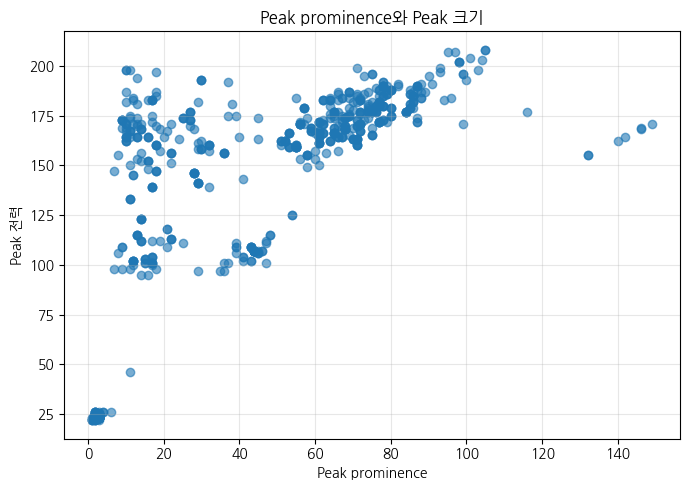

In [45]:
plt.figure(figsize=(7, 5))

plt.scatter(
    peak_df['peak_prominence'],
    peak_df['peak_value'],
    alpha=0.6
)

plt.xlabel("Peak prominence")
plt.ylabel("Peak 전력")

plt.title(
    "Peak prominence와 Peak 크기"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 13. 하루의 최고 Peak와 나머지 Peak 비교

In [46]:
# 하루 안에서 Peak 크기 순위 (1 = 그날 최고 Peak)
peak_df['daily_peak_rank'] = (
    peak_df
    .groupby('date')['peak_value']
    .rank(
        method='first',
        ascending=False
    )
)

display(
    peak_df[
        [
            'date',
            'datetime',
            'peak_value',
            'daily_peak_rank'
        ]
    ]
    .sort_values(
        ['date', 'daily_peak_rank']
    )
    .head(30)
)

,date,datetime,peak_value,daily_peak_rank
0,2021-01-01,2021-01-01 04:00:00,107,1.0
1,2021-01-01,2021-01-01 06:00:00,107,2.0
2,2021-01-02,2021-01-02 04:00:00,107,1.0
3,2021-01-02,2021-01-02 06:00:00,107,2.0
4,2021-01-03,2021-01-03 01:00:00,25,1.0
5,2021-01-03,2021-01-03 21:00:00,25,2.0
6,2021-01-03,2021-01-03 04:00:00,24,3.0
7,2021-01-04,2021-01-04 09:00:00,160,1.0
8,2021-01-04,2021-01-04 13:00:00,155,2.0
9,2021-01-04,2021-01-04 18:00:00,139,3.0


## 14. 요약 테이블 — 현재값 변수의 평일 / 주말 SHAP 중요도

In [47]:
final_comparison = comparison[
    comparison['feature'].isin(
        [
            '생산량',
            '공장인원',
            '기온',
            '습도',
            '풍속',
            '강수량',
            'hour_sin',
            'hour_cos',
            'month_sin',
            'month_cos'
        ]
    )
].copy()

final_comparison = final_comparison[
    [
        'feature',
        'weekday_shap',
        'weekend_shap',
        'difference'
    ]
]

display(
    final_comparison.round(4)
)

,feature,weekday_shap,weekend_shap,difference
28,생산량,17.3034,0.9917,16.311701
0,hour_cos,6.7901,7.1311,-0.341000
12,공장인원,2.7845,0.2040,2.580500
2,month_cos,2.7710,9.0242,-6.253300
1,hour_sin,2.5948,1.3251,1.269700
3,month_sin,1.9517,7.4911,-5.539300
20,기온,0.9217,2.5075,-1.585800
44,풍속,0.8237,1.3557,-0.532000
36,습도,0.7386,1.4232,-0.684600
4,강수량,0.0877,0.0329,0.054800


## 15. 상위 Peak 그룹 분석 (K-Means 계층 분류)
1~9월 전체 시계열에서 Peak를 다시 검출(`distance=6`, `prominence=30`)하고, 전력 크기 기준 K-Means(k=2)를 반복 적용해 계층을 나눈다.
1. 1차 분할: **일반 Peak** vs **극대 Peak**
2. 2차 분할: 극대 Peak 중 **최상위 극대 Peak** 분리

> 이 절에서 `peak_df`를 새로 만들기 때문에, 이후 셀(17절 저장 포함)의 `peak_df`는 이 절의 결과를 가리킨다.

 Peak 계층 분류 결과 요약
              건수  최소 전력   평균 전력  최대 전력
peak_type                             
일반 Peak       45     97  109.04    133
극대 Peak      124    143  167.90    177
최상위 극대 Peak   98    178  187.09    208


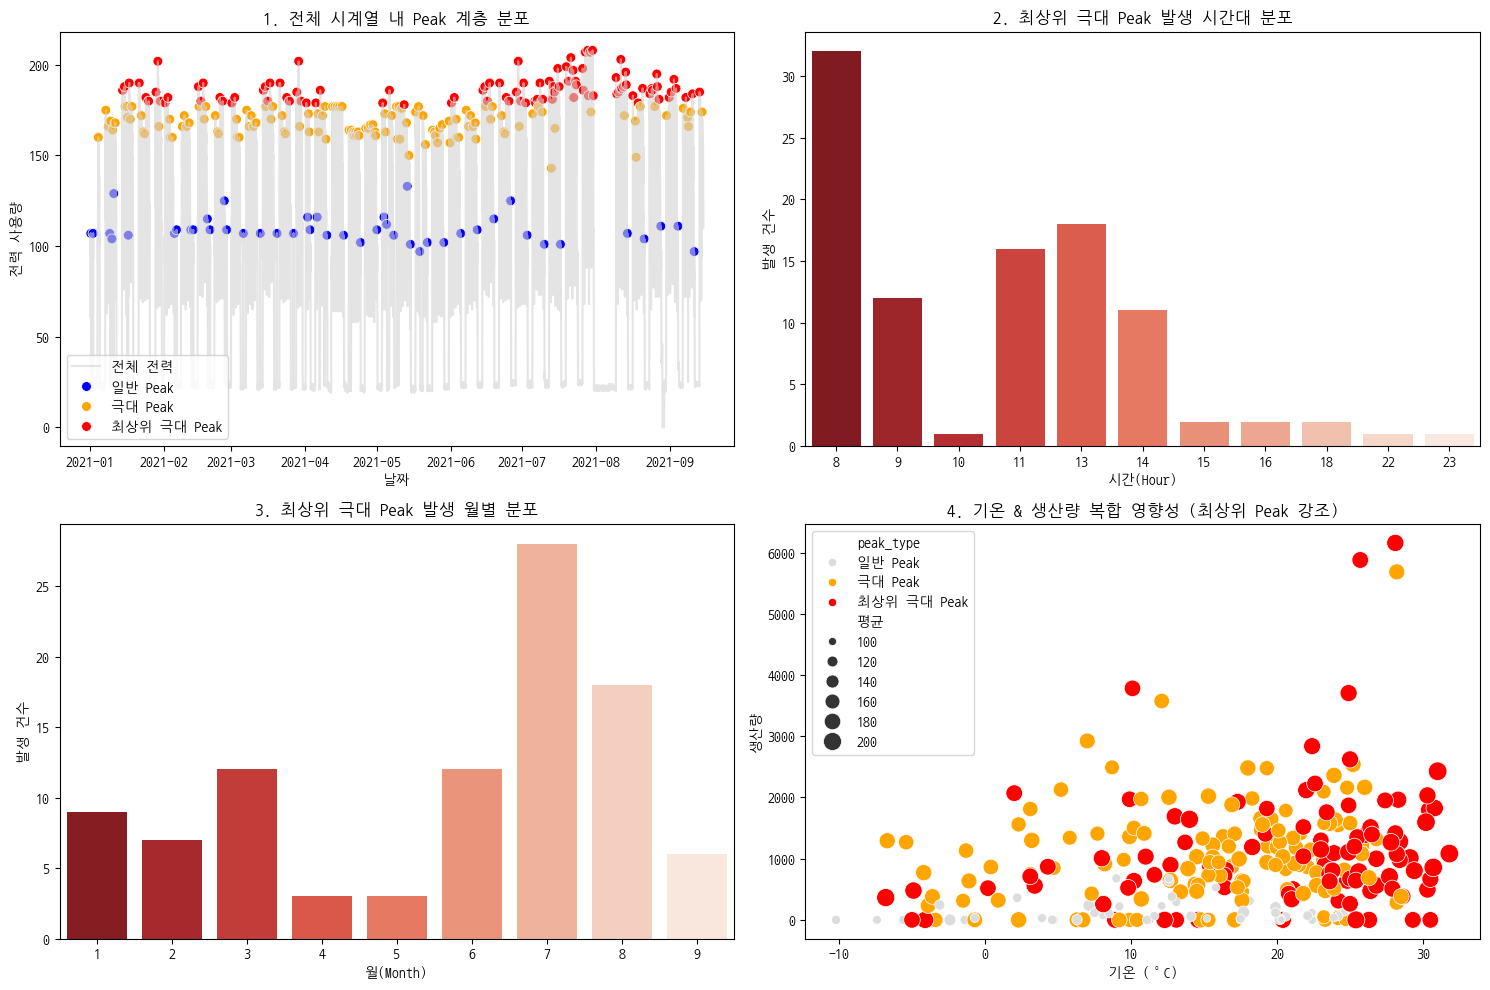

In [48]:
import warnings
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy.signal import find_peaks
from sklearn.cluster import KMeans

# ---------------------------------------------------------
# 0. 한글 폰트 · 경고 설정
# ---------------------------------------------------------
warnings.filterwarnings('ignore')

# 한글 폰트 자동 검색 및 적용
font_set = False
for font in fm.fontManager.ttflist:
    if any(name in font.name for name in ['Malgun Gothic', 'NanumGothic', 'Gothic', 'AppleGothic', 'Gulim', 'Dotum']):
        plt.rc('font', family=font.name)
        font_set = True
        break

if not font_set:
    plt.rc('font', family='sans-serif')

plt.rc('axes', unicode_minus=False)

# ---------------------------------------------------------
# 1. 데이터 준비 (1~9월)
# ---------------------------------------------------------
data = df[(df['m'] >= 1) & (df['m'] <= 9)].copy().reset_index(drop=True)
data['month'] = data['datetime'].dt.month
data['hour'] = data['datetime'].dt.hour
data['weekday_num'] = data['datetime'].dt.weekday
data['day_type'] = np.where(data['weekday_num'] >= 5, '주말', '평일')

# ---------------------------------------------------------
# Step 1. Peak 지점 검출 & 1차 분할 (일반 Peak vs 극대 Peak)
# ---------------------------------------------------------
peaks_idx, _ = find_peaks(data['평균'], distance=6, prominence=30)
peak_df = data.iloc[peaks_idx].copy().reset_index(drop=True)

kmeans1 = KMeans(n_clusters=2, random_state=42)
peak_df['cluster_stage1'] = kmeans1.fit_predict(peak_df[['평균']])
high_cluster_id1 = peak_df.groupby('cluster_stage1')['평균'].mean().idxmax()

peak_df['peak_type'] = np.where(peak_df['cluster_stage1'] == high_cluster_id1, '극대 Peak', '일반 Peak')

# ---------------------------------------------------------
# Step 2. 2차 분할 (극대 Peak 중 '최상위 극대 Peak' 분리)
# ---------------------------------------------------------
high_peaks_mask = peak_df['peak_type'] == '극대 Peak'
high_peaks_df = peak_df[high_peaks_mask].copy()

kmeans2 = KMeans(n_clusters=2, random_state=42)
high_peaks_df['cluster_stage2'] = kmeans2.fit_predict(high_peaks_df[['평균']])
top_cluster_id = high_peaks_df.groupby('cluster_stage2')['평균'].mean().idxmax()

top_indices = high_peaks_df[high_peaks_df['cluster_stage2'] == top_cluster_id].index
peak_df.loc[top_indices, 'peak_type'] = '최상위 극대 Peak'

# ---------------------------------------------------------
# Step 3. '최상위 극대 Peak' 심층 분석 시각화
# ---------------------------------------------------------
top_tier_df = peak_df[peak_df['peak_type'] == '최상위 극대 Peak'].copy()

# 요약 통계 출력
print("="*60)
print(" Peak 계층 분류 결과 요약")
print("="*60)
summary_table = peak_df.groupby('peak_type')['평균'].agg(['count', 'min', 'mean', 'max']).round(2)
summary_table.columns = ['건수', '최소 전력', '평균 전력', '최대 전력']
print(summary_table.reindex(['일반 Peak', '극대 Peak', '최상위 극대 Peak']))

# 그래프 생성 (2x2 구성)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Graph 1: 전체 시계열 내 Peak 위치
axes[0, 0].plot(data['datetime'], data['평균'], color='lightgrey', alpha=0.6, label='전체 전력')
sns.scatterplot(data=peak_df, x='datetime', y='평균', hue='peak_type', 
                hue_order=['일반 Peak', '극대 Peak', '최상위 극대 Peak'],
                palette=['blue', 'orange', 'red'], s=50, ax=axes[0, 0])
axes[0, 0].set_title('1. 전체 시계열 내 Peak 계층 분포')
axes[0, 0].set_xlabel('날짜')
axes[0, 0].set_ylabel('전력 사용량')

axes[0, 0].legend(loc='lower left')

# Graph 2: 최상위 극대 Peak 시간대별 분포
sns.countplot(data=top_tier_df, x='hour', palette='Reds_r', ax=axes[0, 1])
axes[0, 1].set_title('2. 최상위 극대 Peak 발생 시간대 분포')
axes[0, 1].set_xlabel('시간(Hour)')
axes[0, 1].set_ylabel('발생 건수')

# Graph 3: 최상위 극대 Peak 월별 분포
sns.countplot(data=top_tier_df, x='month', palette='Reds_r', ax=axes[1, 0])
axes[1, 0].set_title('3. 최상위 극대 Peak 발생 월별 분포')
axes[1, 0].set_xlabel('월(Month)')
axes[1, 0].set_ylabel('발생 건수')

# Graph 4: 기온 & 생산량 복합 영향성
sns.scatterplot(data=peak_df, x='기온', y='생산량', hue='peak_type',
                hue_order=['일반 Peak', '극대 Peak', '최상위 극대 Peak'],
                palette=['gainsboro', 'orange', 'red'], 
                size='평균', sizes=(30, 180), ax=axes[1, 1])
axes[1, 1].set_title('4. 기온 & 생산량 복합 영향성 (최상위 Peak 강조)')
axes[1, 1].set_xlabel('기온 (°C)')
axes[1, 1].set_ylabel('생산량')

plt.tight_layout()
plt.show()

### 15-1. 초극상위 돌출 Peak 분리 · 특성 비교
최상위 극대 Peak를 전력 기준으로 한 번 더 K-Means 분할해 **초극상위 돌출 Peak**를 분리한다.

'초극상위 돌출 Peak' vs '일반 최상위 Peak' 주요 변수 비교
outlier_peak_type  일반 최상위 Peak  초극상위 돌출 Peak  차이 (돌출 - 일반)
전력 소모량(평균)              184.45        201.73         17.28
생산량                    1151.55       1055.60        -95.95
기온                       19.50         24.83          5.33
공장인원                      1.56          1.30         -0.26
전기요금(계절)                170.06        184.52         14.46

* 초극상위 돌출 Peak 개수: 15개


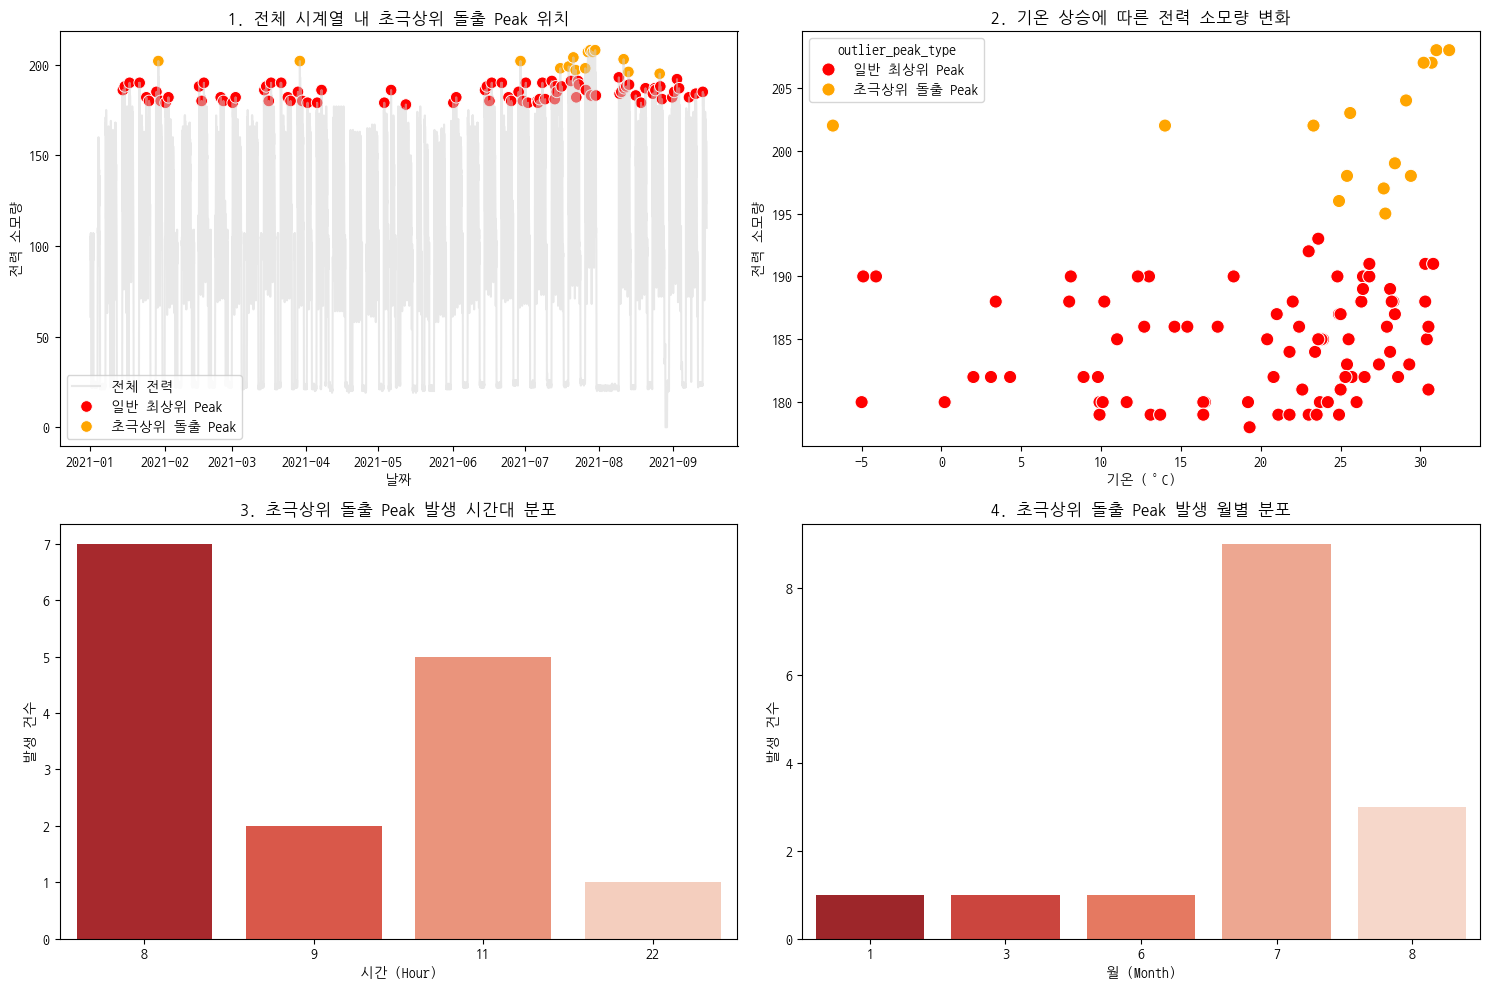


초극상위 돌출 Peak 상세 데이터 (전력 소모량 기준 정렬)
           datetime  전력 소모량   기온  생산량     공장인원  hour  month
2021-07-28 11:00:00     208 31.0 2429 2.926506    11      7
2021-07-30 11:00:00     208 31.8 1084 1.306024    11      7
2021-07-29 11:00:00     207 30.2 1597 1.926417    11      7
2021-07-27 11:00:00     207 30.7  857 1.036276    11      7
2021-07-21 09:00:00     204 29.1 1013 1.244472     9      7
2021-08-11 08:00:00     203 25.6  783 0.964286     8      8
2021-03-29 08:00:00     202 14.0 1644 2.034653     8      3
2021-01-29 08:00:00     202 -6.8  364 0.450495     8      1
2021-06-29 08:00:00     202 23.3  893 1.105198     8      6
2021-07-19 11:00:00     199 28.4 1280 1.606023    11      7
2021-07-15 22:00:00     198 25.4    0 0.000000    22      7
2021-07-26 08:00:00     198 29.4  805 1.017699     8      7
2021-07-22 08:00:00     197 27.7  709 0.902036     8      7
2021-08-13 08:00:00     196 24.9 1107 1.413793     8      8
2021-08-26 09:00:00     195 27.8 1269 1.629012     9      8


In [58]:
# 1. 최상위 극대 Peak
top_tier_df = peak_df[peak_df['peak_type'] == '최상위 극대 Peak'].copy()

# 2. 전력 기준 K-Means(k=2)로 한 번 더 분할 -> '초극상위 돌출 Peak' 분리
kmeans_extreme = KMeans(n_clusters=2, random_state=42)
top_tier_df['extreme_cluster'] = kmeans_extreme.fit_predict(top_tier_df[['평균']])
highest_cluster_id = top_tier_df.groupby('extreme_cluster')['평균'].mean().idxmax()

top_tier_df['outlier_peak_type'] = np.where(
    top_tier_df['extreme_cluster'] == highest_cluster_id, 
    '초극상위 돌출 Peak', 
    '일반 최상위 Peak'
)

# ---------------------------------------------------------
# 3. 돌출 Peak vs 일반 최상위 Peak 특성 비교 출력
# ---------------------------------------------------------
print("="*65)
print("'초극상위 돌출 Peak' vs '일반 최상위 Peak' 주요 변수 비교")
print("="*65)

features_to_compare = ['평균', '생산량', '기온', '공장인원', '전기요금(계절)']
summary_extreme = top_tier_df.groupby('outlier_peak_type')[features_to_compare].mean().round(2).T
summary_extreme.index = ['전력 소모량(평균)', '생산량', '기온', '공장인원', '전기요금(계절)']
summary_extreme['차이 (돌출 - 일반)'] = (summary_extreme['초극상위 돌출 Peak'] - summary_extreme['일반 최상위 Peak']).round(2)
print(summary_extreme)

print(f"\n* 초극상위 돌출 Peak 개수: {len(top_tier_df[top_tier_df['outlier_peak_type'] == '초극상위 돌출 Peak'])}개")

# ---------------------------------------------------------
# 4. 시각화 (2x2)
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# (1) 전체 시계열 내 위치
axes[0, 0].plot(data['datetime'], data['평균'], color='lightgrey', alpha=0.5, label='전체 전력')
sns.scatterplot(
    data=top_tier_df, x='datetime', y='평균', hue='outlier_peak_type',
    palette=['red', 'orange'], s=70, ax=axes[0, 0]
)
axes[0, 0].set_title('1. 전체 시계열 내 초극상위 돌출 Peak 위치')
axes[0, 0].set_xlabel('날짜')
axes[0, 0].set_ylabel('전력 소모량')
axes[0, 0].legend(loc='lower left')

# (2) 기온 vs 전력 소모량
sns.scatterplot(
    data=top_tier_df, x='기온', y='평균', hue='outlier_peak_type',
    palette=['red', 'orange'], s=90, ax=axes[0, 1]
)
axes[0, 1].set_title('2. 기온 상승에 따른 전력 소모량 변화')
axes[0, 1].set_xlabel('기온 (°C)')
axes[0, 1].set_ylabel('전력 소모량')

# (3) 시간대별(Hour) 발생 분포
extreme_only = top_tier_df[top_tier_df['outlier_peak_type'] == '초극상위 돌출 Peak']
sns.countplot(data=extreme_only, x='hour', palette='Reds_r', ax=axes[1, 0])
axes[1, 0].set_title('3. 초극상위 돌출 Peak 발생 시간대 분포')
axes[1, 0].set_xlabel('시간 (Hour)')
axes[1, 0].set_ylabel('발생 건수')

# (4) 월별(Month) 발생 분포
sns.countplot(data=extreme_only, x='month', palette='Reds_r', ax=axes[1, 1])
axes[1, 1].set_title('4. 초극상위 돌출 Peak 발생 월별 분포')
axes[1, 1].set_xlabel('월 (Month)')
axes[1, 1].set_ylabel('발생 건수')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. 초극상위 돌출 Peak 상세 데이터
# ---------------------------------------------------------
print("\n" + "="*65)
print("초극상위 돌출 Peak 상세 데이터 (전력 소모량 기준 정렬)")
print("="*65)
extreme_list = extreme_only.sort_values(by='평균', ascending=False).copy()
extreme_list_display = extreme_list[['datetime', '평균', '기온', '생산량', '공장인원', 'hour', 'month']].copy()
extreme_list_display.columns = ['datetime', '전력 소모량', '기온', '생산량', '공장인원', 'hour', 'month']
print(extreme_list_display.to_string(index=False))

### 15-2. 초극상위 Peak 원인 추정 (규칙 기반)

| 조건 | 기준 |
|---|---|
| 고온 | 기온 ≥ 전체 상위 25% |
| 고생산 | 생산량 ≥ 전체 상위 25% |
| 고습도 | 습도 ≥ 80% |
| 폭우 | 강수량 ≥ 10mm |

조건 조합으로 원인을 분류하고, 해당 없으면 시각(8 · 9 · 13시 = 정상 기동)으로 기동 스파이크 여부를 구분한다.

In [66]:
# 1. 초극상위 돌출 Peak 재추출 (15-1과 동일)
top_tier_df = peak_df[peak_df['peak_type'] == '최상위 극대 Peak'].copy()

kmeans_extreme = KMeans(n_clusters=2, random_state=42)
top_tier_df['extreme_cluster'] = kmeans_extreme.fit_predict(top_tier_df[['평균']])
highest_cluster_id = top_tier_df.groupby('extreme_cluster')['평균'].mean().idxmax()

extreme_only = top_tier_df[top_tier_df['extreme_cluster'] == highest_cluster_id].copy()

# 2. 기준점: 기온 · 생산량 상위 25% (1~9월 전체 데이터 기준)
q_temp_top = data['기온'].quantile(0.75)   # 상위 25% 기온 (약 23.3°C)
q_prod_top = data['생산량'].quantile(0.75) # 상위 25% 생산량 (약 780개)

# 3. 규칙 기반 원인 추정 (기온 · 생산량 · 습도 · 강수량)
def predict_peak_reason_weather(row):
    is_high_temp = row['기온'] >= q_temp_top
    is_high_prod = row['생산량'] >= q_prod_top
    is_high_humid = row['습도'] >= 80.0  # 고습도 기준점 (80% 이상)
    is_heavy_rain = row['강수량'] >= 10.0 # 강우량 10mm 이상

    # (1) 기상 특수 조건(폭우 / 고습도 단독) 우선 판별
    if is_heavy_rain:
        return '기록적 폭우 (배수/수해방지 설비 과부하)'
    elif is_high_humid and not is_high_prod and not is_high_temp:
        return '고습도 환경 (제습/항온항습 설비 풀가동)'

    # (2) 기온 · 생산량 · 습도 조합
    if is_high_temp and is_high_prod:
        if is_high_humid:
            return '폭염·고습도·생산 풀가동 (최대 복합 과부하)'
        return '폭염 및 생산 풀가동 (복합 과부하)'
    elif is_high_temp and not is_high_prod:
        if is_high_humid:
            return '고온·고습에 따른 냉방/제습 과부하'
        return '폭염/고온에 따른 냉방 부하'
    elif not is_high_temp and is_high_prod:
        return '생산량 급증에 따른 설비 풀가동'
    else:
        if row['hour'] in [8, 9, 13]:
            return '정상 기동 스파이크 (출근/점심후 예열)'
        else:
            return '비정상 기동 스파이크 (추가 분석 필요)'

extreme_only['추정_발생원인'] = extreme_only.apply(predict_peak_reason_weather, axis=1)

# ---------------------------------------------------------
# 4. 결과 출력
# ---------------------------------------------------------
print("="*85)
print("초극상위 돌출 Peak 원인별 요약 (습도 & 강수량 연동)")
print("="*85)
print(extreme_only['추정_발생원인'].value_counts())

print("\n" + "="*85)
print("개별 초극상위 Peak 지점별 상세 예측 내역 (습도/강수량 포함)")
print("="*85)
result_display = extreme_only[
    ['datetime', '평균', '기온', '습도', '강수량', '생산량', '공장인원', 'hour', '추정_발생원인']
].copy()

result_display.columns = [
    '날짜/시간', '전력소모량(kW)', '기온(°C)', '습도(%)', '강수량(mm)', '생산량(개)', '공장인원', '시(Hour)', '추정 발생 원인'
]
print(result_display.sort_values(by='전력소모량(kW)', ascending=False).to_string(index=False))

 초극상위 돌출 Peak 원인별 요약 (습도 & 강수량 연동)
추정_발생원인
폭염 및 생산 풀가동 (복합 과부하)         9
폭염·고습도·생산 풀가동 (최대 복합 과부하)    3
정상 기동 스파이크 (출근/점심후 예열)       1
생산량 급증에 따른 설비 풀가동            1
고온·고습에 따른 냉방/제습 과부하          1
Name: count, dtype: int64

개별 초극상위 Peak 지점별 상세 예측 내역 (습도/강수량 포함)
              날짜/시간  전력소모량(kW)  기온(°C)  습도(%)  강수량(mm)  생산량(개)     공장인원  시(Hour)                  추정 발생 원인
2021-07-28 11:00:00        208    31.0     65      0.0    2429 2.926506       11      폭염 및 생산 풀가동 (복합 과부하)
2021-07-30 11:00:00        208    31.8     59      0.0    1084 1.306024       11      폭염 및 생산 풀가동 (복합 과부하)
2021-07-29 11:00:00        207    30.2     61      0.0    1597 1.926417       11      폭염 및 생산 풀가동 (복합 과부하)
2021-07-27 11:00:00        207    30.7     65      0.0     857 1.036276       11      폭염 및 생산 풀가동 (복합 과부하)
2021-07-21 09:00:00        204    29.1     72      0.0    1013 1.244472        9      폭염 및 생산 풀가동 (복합 과부하)
2021-08-11 08:00:00        203    25.6     94      0.0     783 0.964286        8 폭염·고습도·생산 풀가동 

## 16. 생산량 구간별 기온 · 습도와 전력의 관계
기동 스파이크 시각(8 · 9 · 13시)을 제외하고 생산량 조건을 고정한 뒤, 기온(2℃ 간격) · 습도(10% 간격)에 따른 평균 전력을 비교한다.

### 16-1. 생산량 300~1,000 구간

1. [생산량 300~1000 & 기동 스파이크 제외] 기온 하락에 따른 전력 Peak 감소 추이
   기온_구간       평균전력  최대전력  피크_190kW이상_건수  샘플수  전력_감소량(kW)
[15, 17) 126.072727   180              0   55         NaN
[17, 19) 130.250000   178              0   48    4.177273
[19, 21) 128.819444   179              0   72   -1.430556
[21, 23) 128.577778   187              0   90   -0.241667
[23, 25) 133.669903   185              0  103    5.092125
[25, 27) 139.821429   190              1   56    6.151526
[27, 29) 156.548387   187              0   31   16.726959
[29, 31) 163.555556   207              2   18    7.007168
[31, 33) 186.500000   188              0    2   22.944444
[33, 35) 161.000000   161              0    1  -25.500000

2. [생산량 300~1000 & 기동 스파이크 제외] 습도 하락에 따른 전력 Peak 감소 추이
    습도_구간       평균전력  최대전력  피크_190kW이상_건수  샘플수  전력_감소량(kW)
 [30, 40) 127.841270   182              0   63         NaN
 [40, 50) 125.981818   177              0   55   -1.859452
 [50, 60) 133.219512   189              0   82    7.237694
 [60, 70) 143.3

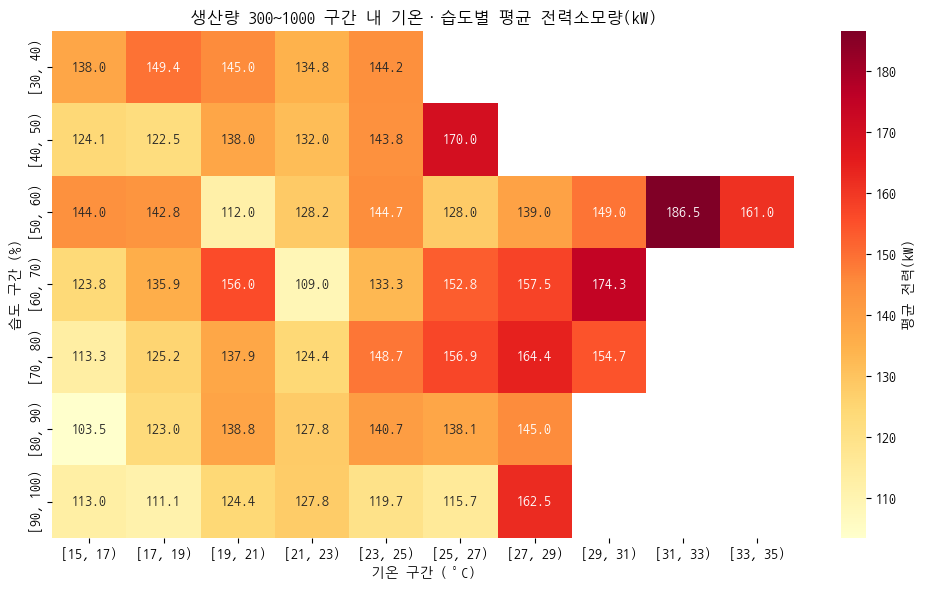

In [72]:
# ---------------------------------------------------------
# 1. 조건 필터
#    - 기동 스파이크 시각(8 · 9 · 13시) 제외
#    - 300 <= 생산량 <= 1000
# ---------------------------------------------------------
spike_hours = [8, 9, 13]

filtered_data = data[
    (~data['hour'].isin(spike_hours)) & 
    (data['생산량'] >= 300) & 
    (data['생산량'] <= 1000)
].copy().reset_index(drop=True)

# ---------------------------------------------------------
# 2. 기온(2℃) · 습도(10%) 구간화
# ---------------------------------------------------------
filtered_data['기온_구간'] = pd.cut(
    filtered_data['기온'], 
    bins=range(15, 36, 2), 
    right=False
)
filtered_data['습도_구간'] = pd.cut(
    filtered_data['습도'], 
    bins=range(30, 101, 10), 
    right=False
)

# (1) 기온 구간별 전력 (diff = 이전 구간 대비 변화)
temp_analysis = filtered_data.groupby('기온_구간', observed=False).agg(
    평균전력=('평균', 'mean'),
    최대전력=('평균', 'max'),
    피크_190kW이상_건수=('평균', lambda x: (x >= 190).sum()),
    샘플수=('평균', 'count')
).reset_index()

temp_analysis['전력_감소량(kW)'] = temp_analysis['평균전력'].diff()

# (2) 습도 구간별 전력
humid_analysis = filtered_data.groupby('습도_구간', observed=False).agg(
    평균전력=('평균', 'mean'),
    최대전력=('평균', 'max'),
    피크_190kW이상_건수=('평균', lambda x: (x >= 190).sum()),
    샘플수=('평균', 'count')
).reset_index()

humid_analysis['전력_감소량(kW)'] = humid_analysis['평균전력'].diff()

# ---------------------------------------------------------
# 3. 결과 출력
# ---------------------------------------------------------
print("="*85)
print("1. [생산량 300~1000 & 기동 스파이크 제외] 기온 하락에 따른 전력 Peak 감소 추이")
print("="*85)
print(temp_analysis.to_string(index=False))

print("\n" + "="*85)
print("2. [생산량 300~1000 & 기동 스파이크 제외] 습도 하락에 따른 전력 Peak 감소 추이")
print("="*85)
print(humid_analysis.to_string(index=False))

# ---------------------------------------------------------
# 4. 시각화: 기온 × 습도 평균 전력 히트맵
# ---------------------------------------------------------
heatmap_data = filtered_data.pivot_table(
    index='습도_구간', 
    columns='기온_구간', 
    values='평균', 
    aggfunc='mean',
    observed=False
)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': '평균 전력(kW)'})
plt.title("생산량 300~1000 구간 내 기온·습도별 평균 전력소모량(kW)")
plt.xlabel("기온 구간 (°C)")
plt.ylabel("습도 구간 (%)")
plt.tight_layout()
plt.show()

### 16-2. 생산량 그룹별 기온 민감도
- 그룹 1: 500 ≤ 생산량 < 1,000
- 그룹 2: 1,000 ≤ 생산량 ≤ 1,500 (Peak 집중 구간)

> ⚠️ 이 셀은 다음 셀(16-3)에서 만드는 `data_filtered`를 사용하므로, **16-3 셀을 먼저 실행**해야 한다.

In [76]:
# ---------------------------------------------------------
# 생산량 그룹 (data_filtered는 16-3 셀에서 생성)
#    - 그룹 1: 500 <= 생산량 < 1000
#    - 그룹 2: 1000 <= 생산량 <= 1500
# ---------------------------------------------------------
cond_group1 = (data_filtered['생산량'] >= 500) & (data_filtered['생산량'] < 1000)
cond_group2 = (data_filtered['생산량'] >= 1000) & (data_filtered['생산량'] <= 1500)

df_g1 = data_filtered[cond_group1].copy()
df_g2 = data_filtered[cond_group2].copy()

def analyze_weather_sensitivity(input_df):
    df_copy = input_df.copy()
    
    # 기온(2℃) · 습도(10%) 구간화
    df_copy['기온_구간'] = pd.cut(df_copy['기온'], bins=range(15, 36, 2), right=False)
    df_copy['습도_구간'] = pd.cut(df_copy['습도'], bins=range(30, 101, 10), right=False)
    
    # 기온 구간별
    temp_agg = df_copy.groupby('기온_구간', observed=False).agg(
        평균전력=('평균', 'mean'),
        최대전력=('평균', 'max'),
        피크_190kW이상_건수=('평균', lambda x: (x >= 190).sum()),
        샘플수=('평균', 'count')
    ).reset_index()
    temp_agg['전력_감소량(kW)'] = temp_agg['평균전력'].diff()
    
    # 습도 구간별
    humid_agg = df_copy.groupby('습도_구간', observed=False).agg(
        평균전력=('평균', 'mean'),
        최대전력=('평균', 'max'),
        피크_190kW이상_건수=('평균', lambda x: (x >= 190).sum()),
        샘플수=('평균', 'count')
    ).reset_index()
    humid_agg['전력_감소량(kW)'] = humid_agg['평균전력'].diff()
    
    return temp_agg, humid_agg, df_copy

# 분석 실행
temp_g1, humid_g1, df_g1_binned = analyze_weather_sensitivity(df_g1)
temp_g2, humid_g2, df_g2_binned = analyze_weather_sensitivity(df_g2)

# 결과 출력
print("="*85)
print("📌 [그룹 1: 생산량 500~1000개] 기온 하락에 따른 전력 Peak 감소 추이")
print("="*85)
print(temp_g1.to_string(index=False))

print("\n" + "="*85)
print("📌 [그룹 2: 생산량 1000~1500개 (Peak 집중구간)] 기온 하락에 따른 전력 Peak 감소 추이")
print("="*85)
print(temp_g2.to_string(index=False))

📌 [그룹 1: 생산량 500~1000개] 기온 하락에 따른 전력 Peak 감소 추이
   기온_구간       평균전력  최대전력  피크_190kW이상_건수  샘플수  전력_감소량(kW)
[15, 17) 141.068966   180              0   29         NaN
[17, 19) 135.529412   178              0   34   -5.539554
[19, 21) 132.938776   179              0   49   -2.590636
[21, 23) 143.744186   182              0   43   10.805411
[23, 25) 140.181818   185              0   66   -3.562368
[25, 27) 151.459459   190              1   37   11.277641
[27, 29) 157.208333   187              0   24    5.748874
[29, 31) 170.714286   207              2   14   13.505952
[31, 33) 185.000000   185              0    1   14.285714
[33, 35) 161.000000   161              0    1  -24.000000

📌 [그룹 2: 생산량 1000~1500개 (Peak 집중구간)] 기온 하락에 따른 전력 Peak 감소 추이
   기온_구간       평균전력  최대전력  피크_190kW이상_건수  샘플수  전력_감소량(kW)
[15, 17) 147.714286   173              0   21         NaN
[17, 19) 148.388889   193              1   18    0.674603
[19, 21) 151.114286   177              0   35    2.725397
[21, 23) 148.333333 

### 16-3. 생산량 그룹별 기온 × 습도 히트맵

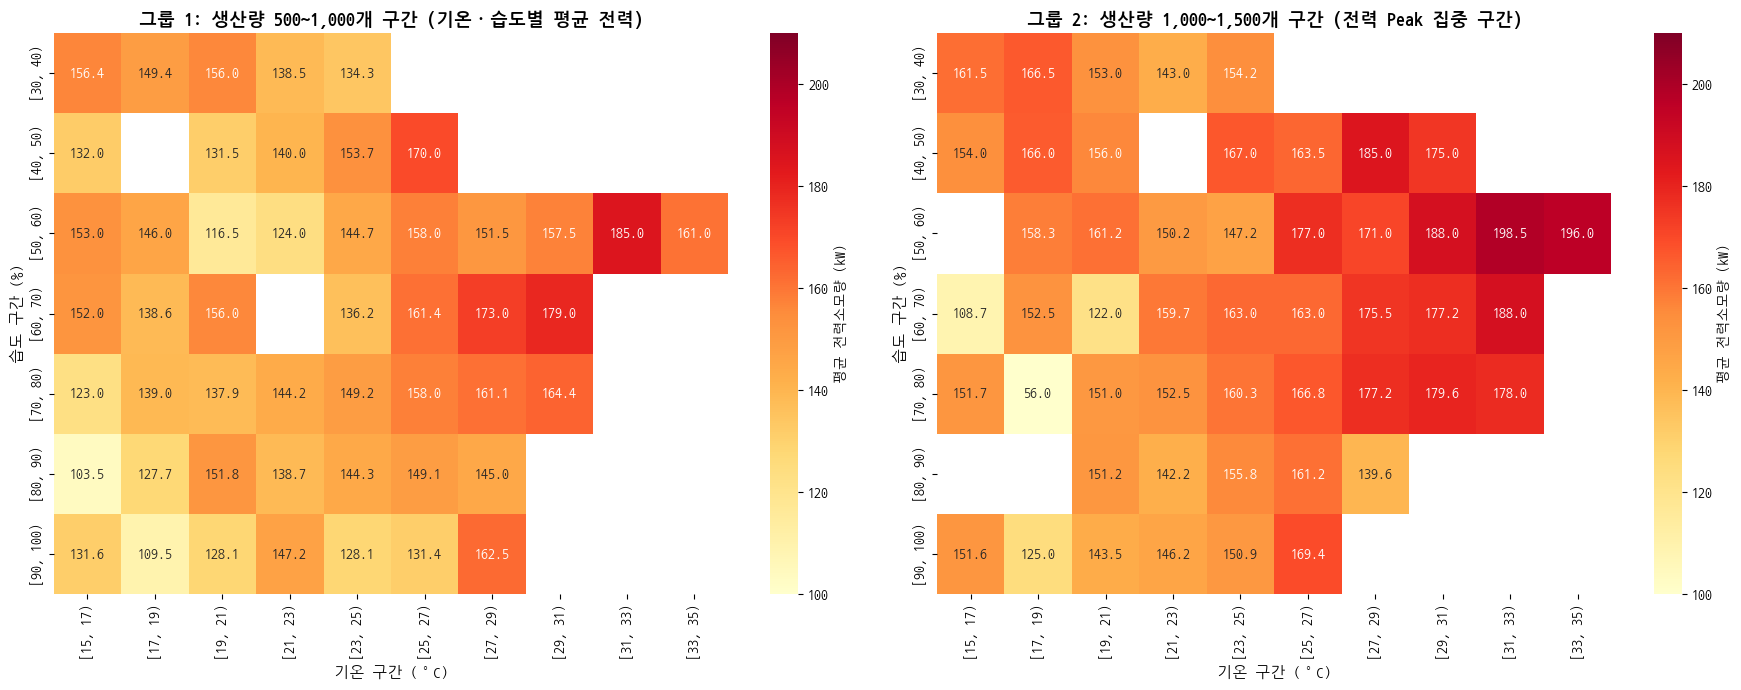

In [77]:
# 1~9월, 기동 스파이크 시각(8 · 9 · 13시) 제외
spike_hours = [8, 9, 13]
data_filtered = df[(df['m'] >= 1) & (df['m'] <= 9) & (~df['시간'].isin(spike_hours))].copy()

# ---------------------------------------------------------
# 생산량 그룹 필터링
# ---------------------------------------------------------
df_g1 = data_filtered[(data_filtered['생산량'] >= 500) & (data_filtered['생산량'] < 1000)].copy()
df_g2 = data_filtered[(data_filtered['생산량'] >= 1000) & (data_filtered['생산량'] <= 1500)].copy()

# 기온(2℃) · 습도(10%) 구간
for target_df in [df_g1, df_g2]:
    target_df['기온_구간'] = pd.cut(target_df['기온'], bins=range(15, 36, 2), right=False)
    target_df['습도_구간'] = pd.cut(target_df['습도'], bins=range(30, 101, 10), right=False)

# 기온 × 습도별 평균 전력
heatmap_g1 = df_g1.pivot_table(index='습도_구간', columns='기온_구간', values='평균', aggfunc='mean', observed=False)
heatmap_g2 = df_g2.pivot_table(index='습도_구간', columns='기온_구간', values='평균', aggfunc='mean', observed=False)

# ---------------------------------------------------------
# 히트맵
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# (좌) 그룹 1: 생산량 500~1000개
sns.heatmap(
    heatmap_g1, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[0],
    cbar_kws={'label': '평균 전력소모량 (kW)'}, vmin=100, vmax=210
)
axes[0].set_title("그룹 1: 생산량 500~1,000개 구간 (기온·습도별 평균 전력)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("기온 구간 (°C)", fontsize=11)
axes[0].set_ylabel("습도 구간 (%)", fontsize=11)

# (우) 그룹 2: 생산량 1000~1,500개 (전력 Peak 집중 구간)
sns.heatmap(
    heatmap_g2, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1],
    cbar_kws={'label': '평균 전력소모량 (kW)'}, vmin=100, vmax=210
)
axes[1].set_title("그룹 2: 생산량 1,000~1,500개 구간 (전력 Peak 집중 구간)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("기온 구간 (°C)", fontsize=11)
axes[1].set_ylabel("습도 구간 (%)", fontsize=11)

plt.tight_layout()
plt.show()

## 17. 분석 결과 저장
Peak 데이터 · 통계 · 상관계수 · 회귀 결과 · SHAP 중요도를 `peak_factor_analysis_result.xlsx`에 시트별로 저장한다.

In [50]:
output_file = 'peak_factor_analysis_result.xlsx'

with pd.ExcelWriter(
    output_file,
    engine='openpyxl'
) as writer:
    
    peak_df.to_excel(
        writer,
        sheet_name='Peak_Data',
        index=False
    )
    
    summary.to_excel(
        writer,
        sheet_name='Peak_Summary'
    )
    
    weekday_corr.to_frame(
        'correlation'
    ).to_excel(
        writer,
        sheet_name='Weekday_Correlation'
    )
    
    weekend_corr.to_frame(
        'correlation'
    ).to_excel(
        writer,
        sheet_name='Weekend_Correlation'
    )
    
    regression_table(
        weekday_model_current
    ).to_excel(
        writer,
        sheet_name='Weekday_Regression'
    )
    
    regression_table(
        weekend_model_current
    ).to_excel(
        writer,
        sheet_name='Weekend_Regression'
    )
    
    regression_table(
        weekday_model_past
    ).to_excel(
        writer,
        sheet_name='Weekday_Past_Regression'
    )
    
    regression_table(
        weekend_model_past
    ).to_excel(
        writer,
        sheet_name='Weekend_Past_Regression'
    )
    
    weekday_shap_importance.to_excel(
        writer,
        sheet_name='Weekday_SHAP',
        index=False
    )
    
    weekend_shap_importance.to_excel(
        writer,
        sheet_name='Weekend_SHAP',
        index=False
    )
    
    comparison.to_excel(
        writer,
        sheet_name='Weekday_vs_Weekend',
        index=False
    )

print(
    f"결과 저장 완료: {output_file}"
)

결과 저장 완료: peak_factor_analysis_result.xlsx
